In [1]:
import importlib
import biascodefunction

# Reload the updated .py file
importlib.reload(biascodefunction)
print("biascodefunction.py reloaded successfully.")

import importlib
import bias

# Reload the newest saved version of bias.py
importlib.reload(bias)

biascodefunction.py reloaded successfully.


<module 'bias' from '\\\\ad.monash.edu\\home\\User029\\slok0019\\Documents\\BSEN1990 2023\\bias.py'>

Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.0333
----------------------------------------------------------------------
Target density   = 0.0333
Actual density   = 0.0300
Total peds       = 3
Tocity, Outcity  = 1, 

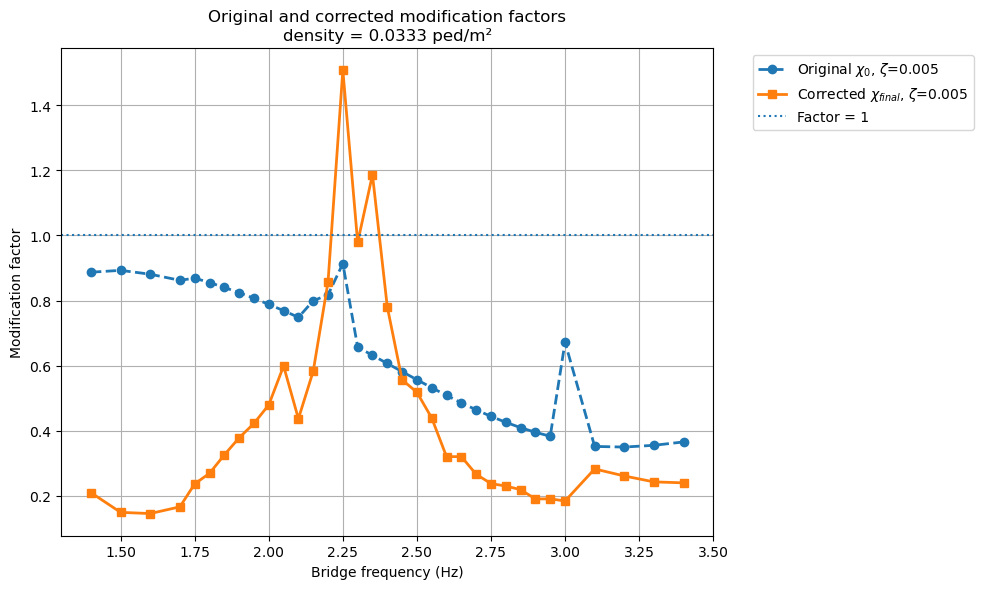

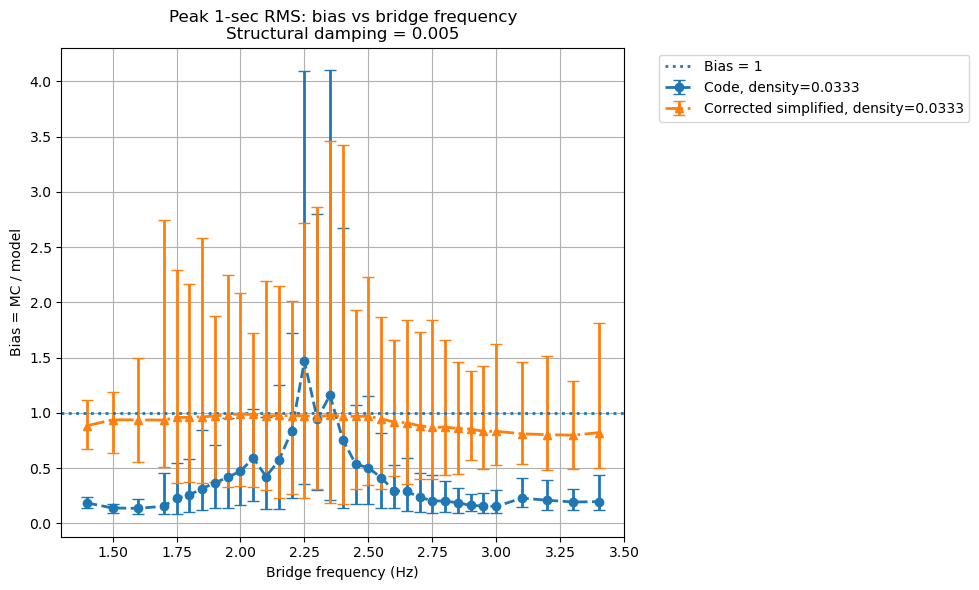

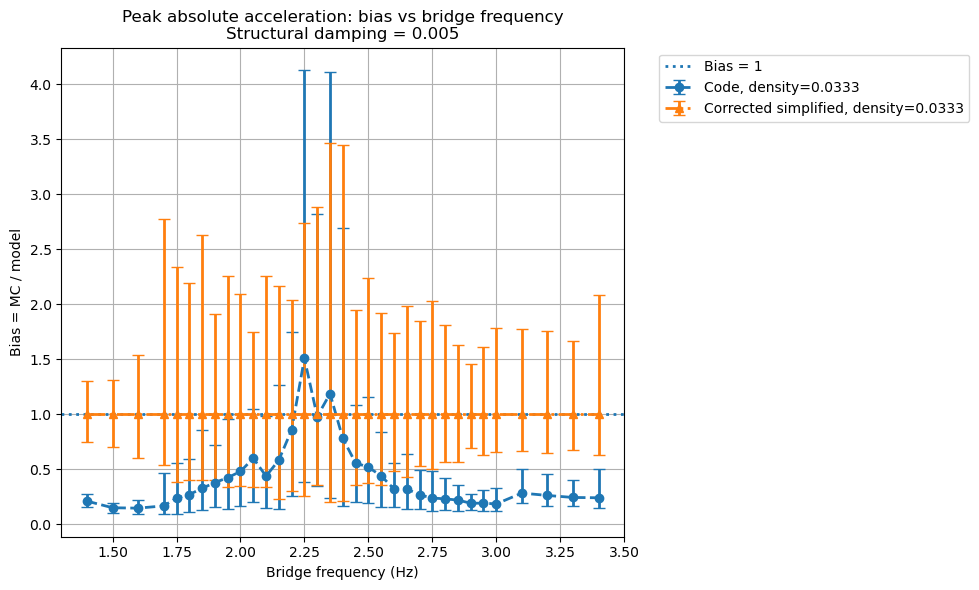

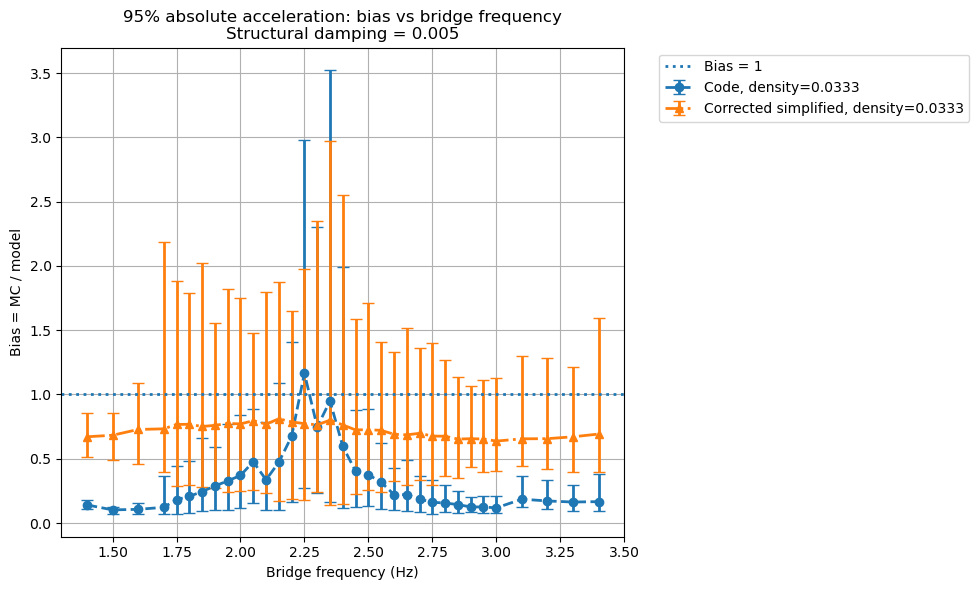

In [2]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.0333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.0333_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.0333_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.1667
----------------------------------------------------------------------
Target density   = 0.1667
Actual density   = 0.1700
Total peds       = 17
Tocity, Outcity  = 8,

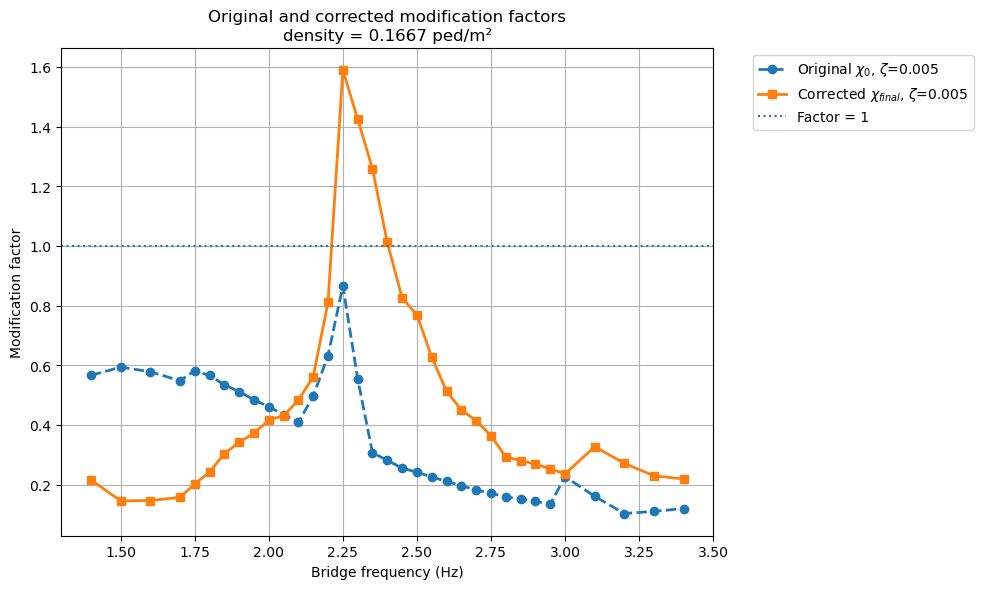

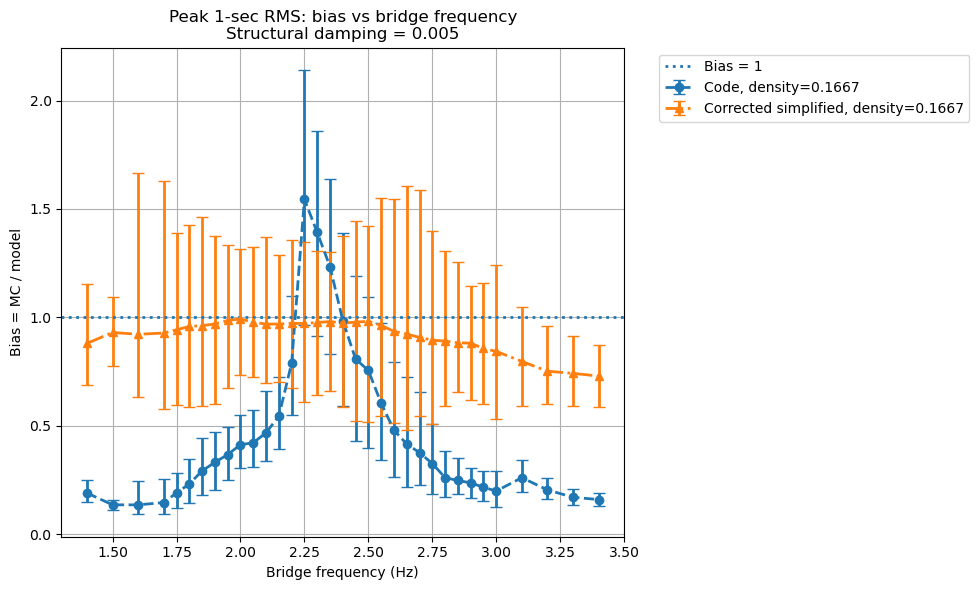

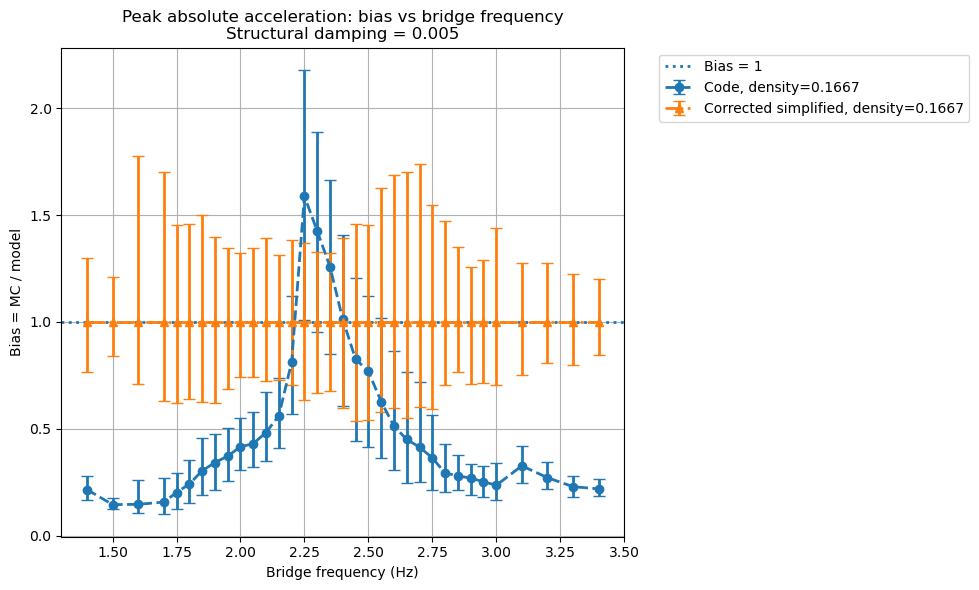

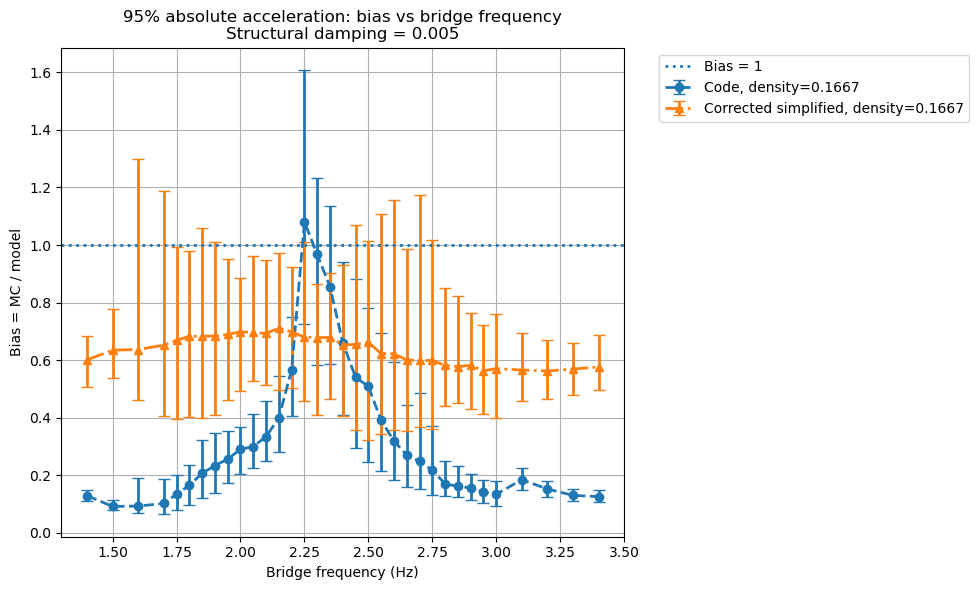

In [3]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.1667_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.1667_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.3333
----------------------------------------------------------------------
Target density   = 0.3333
Actual density   = 0.3300
Total peds       = 33
Tocity, Outcity  = 16

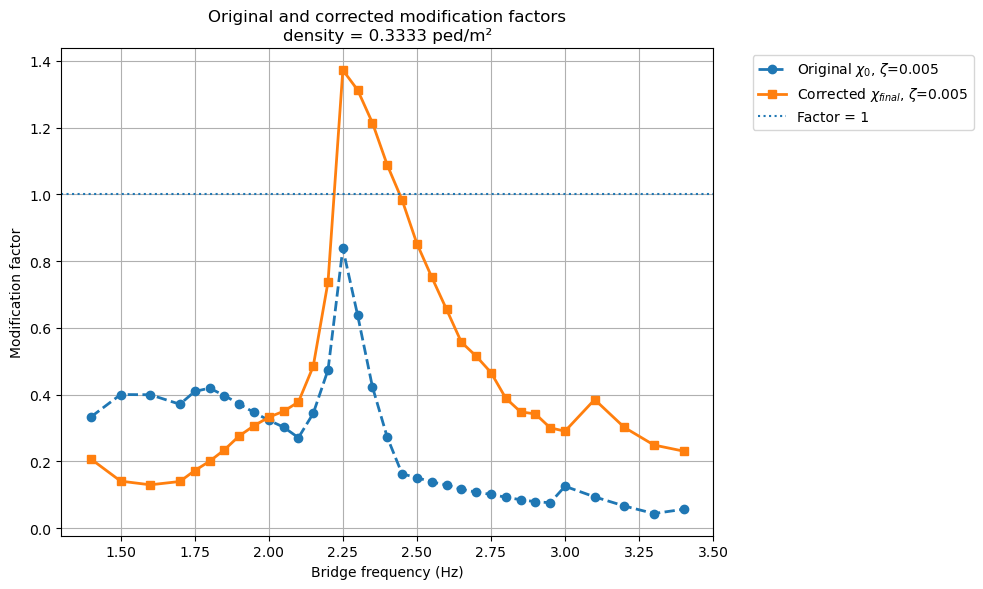

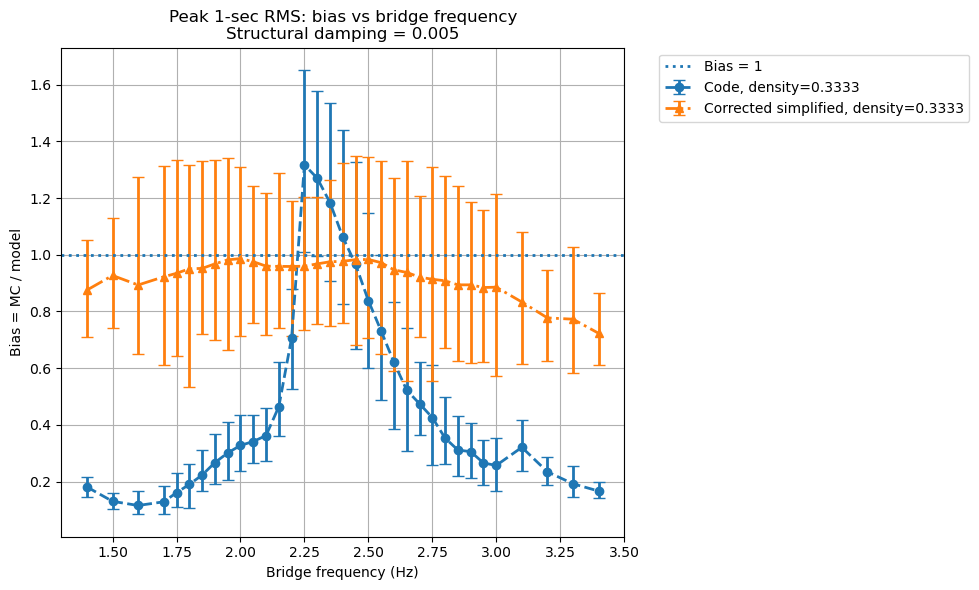

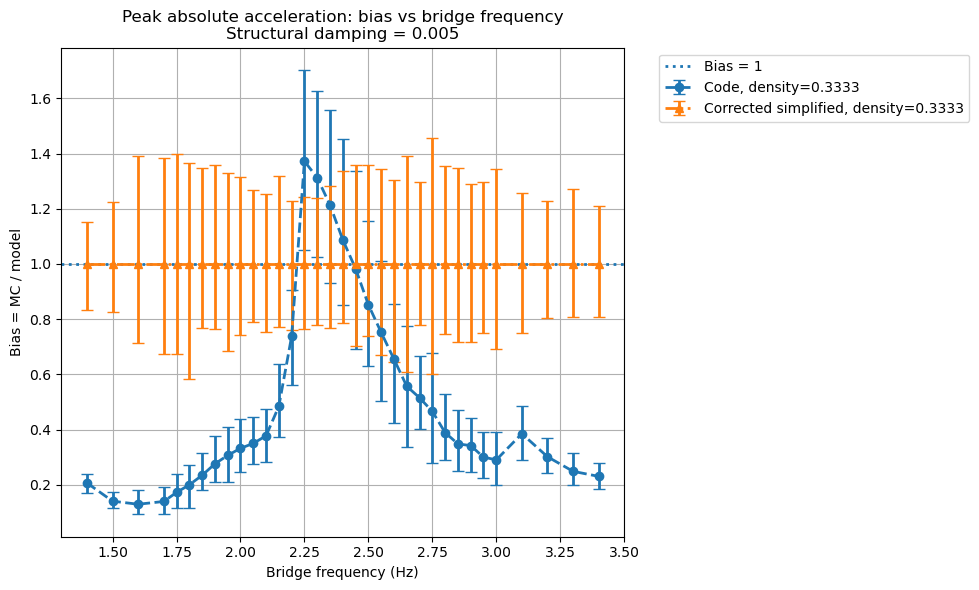

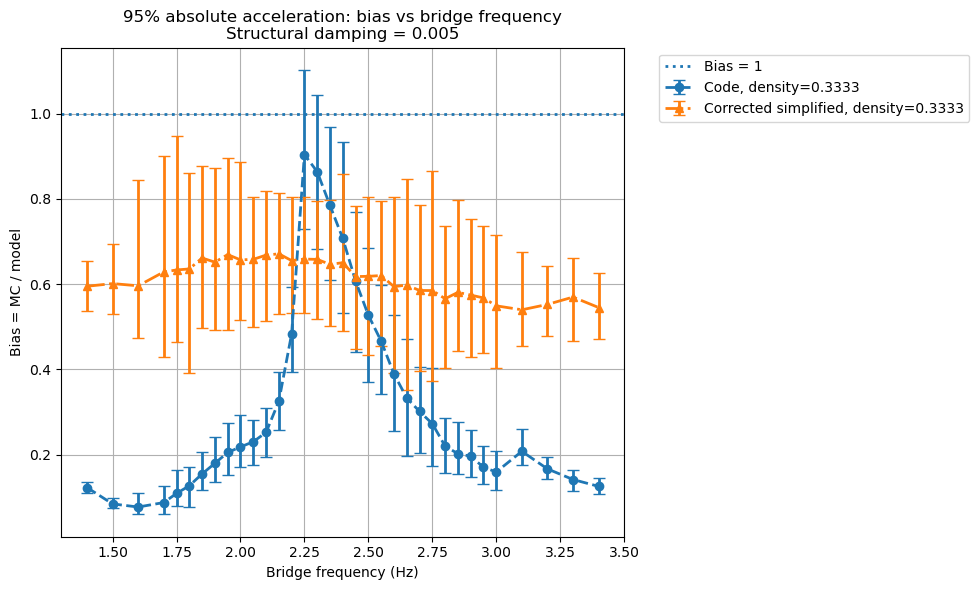

In [4]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.3333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.3333_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.3333_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.5000
----------------------------------------------------------------------
Target density   = 0.5000
Actual density   = 0.5000
Total peds       = 50
Tocity, Outcity  = 25

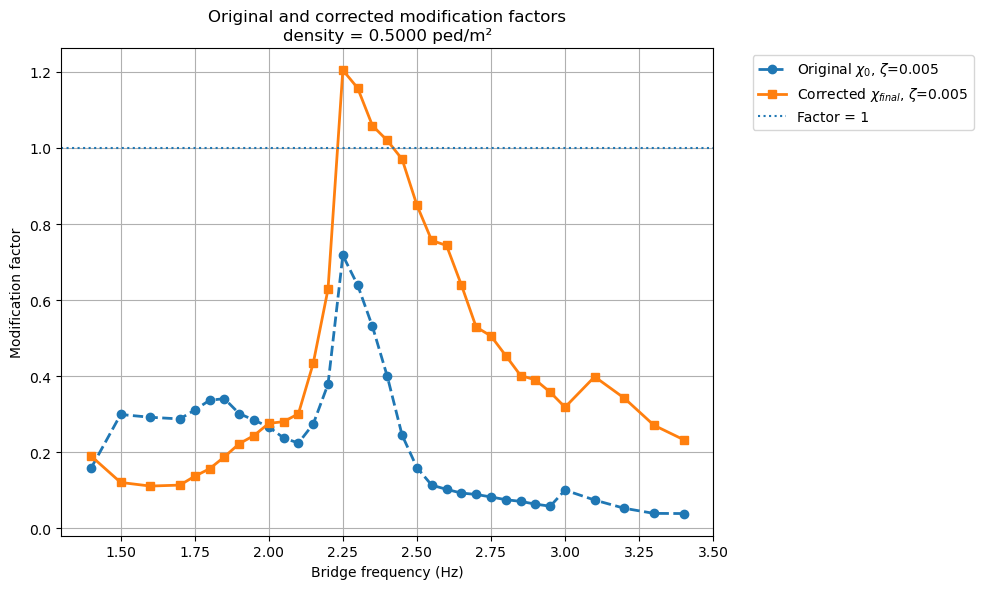

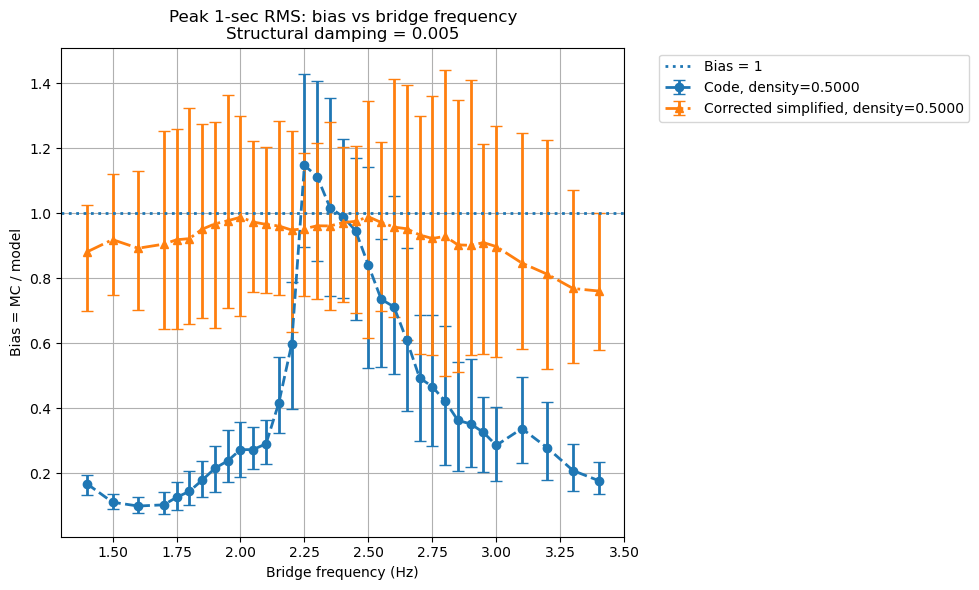

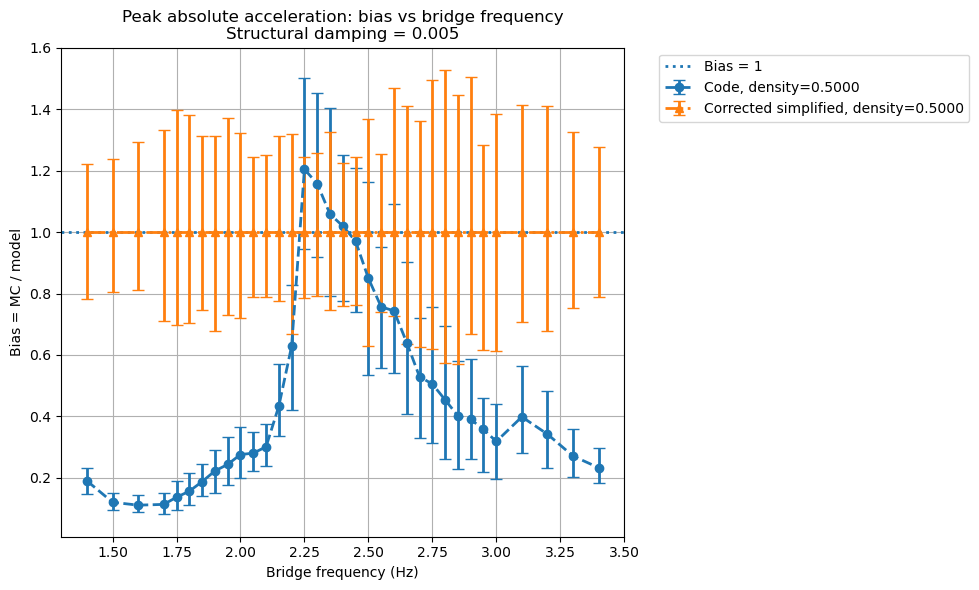

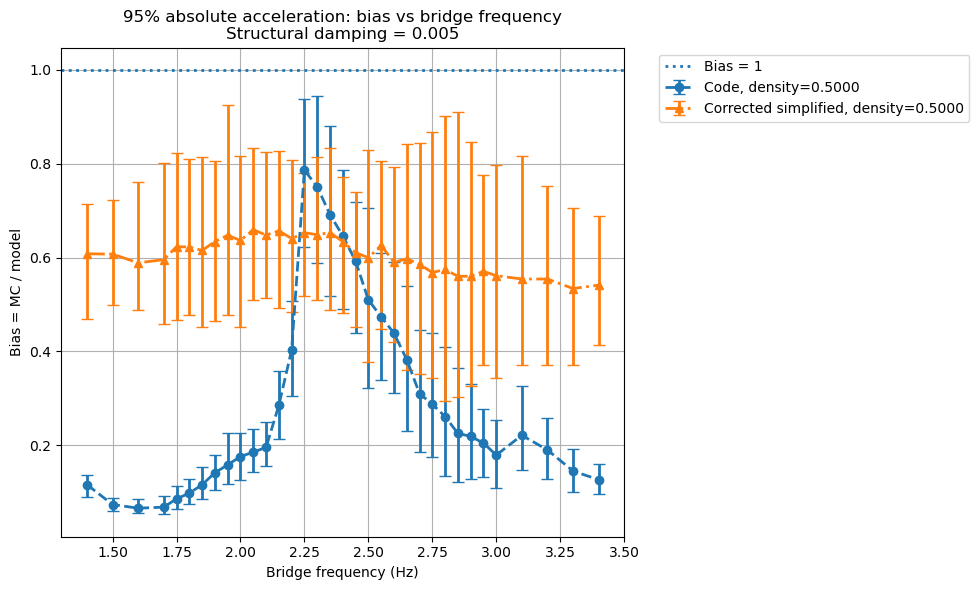

In [5]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.5000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.5000_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.5000_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.6667
----------------------------------------------------------------------
Target density   = 0.6667
Actual density   = 0.6700
Total peds       = 67
Tocity, Outcity  = 33

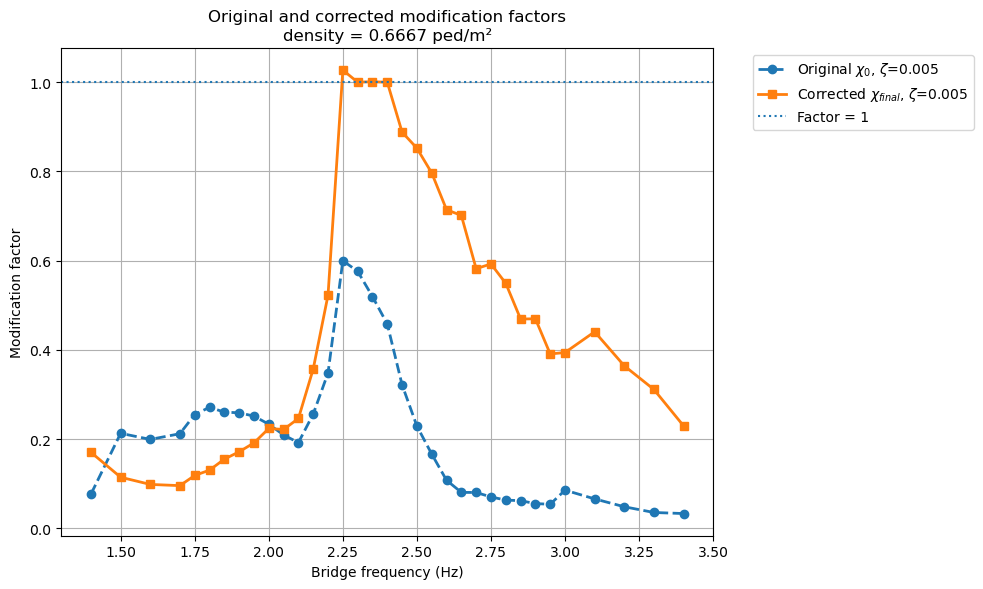

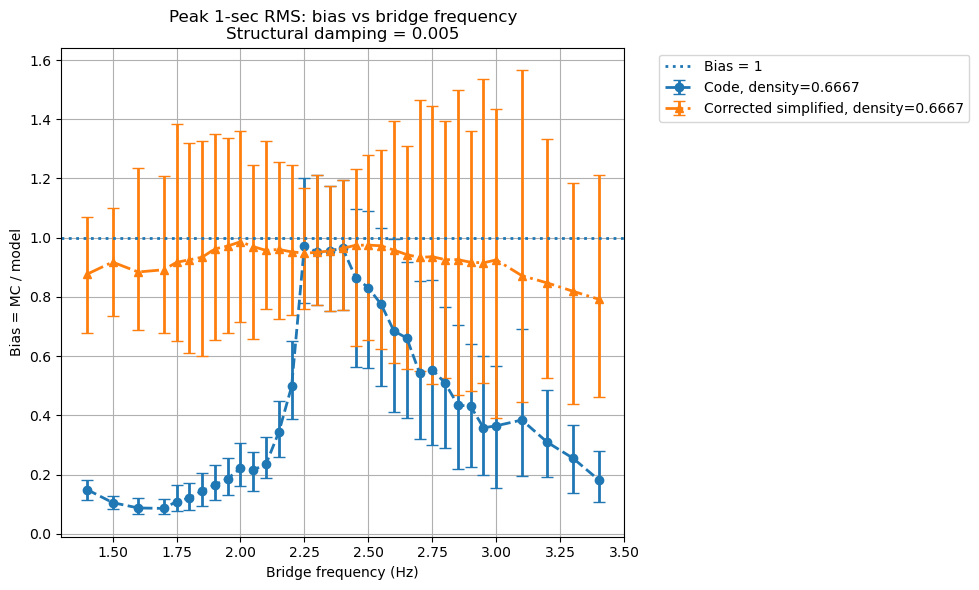

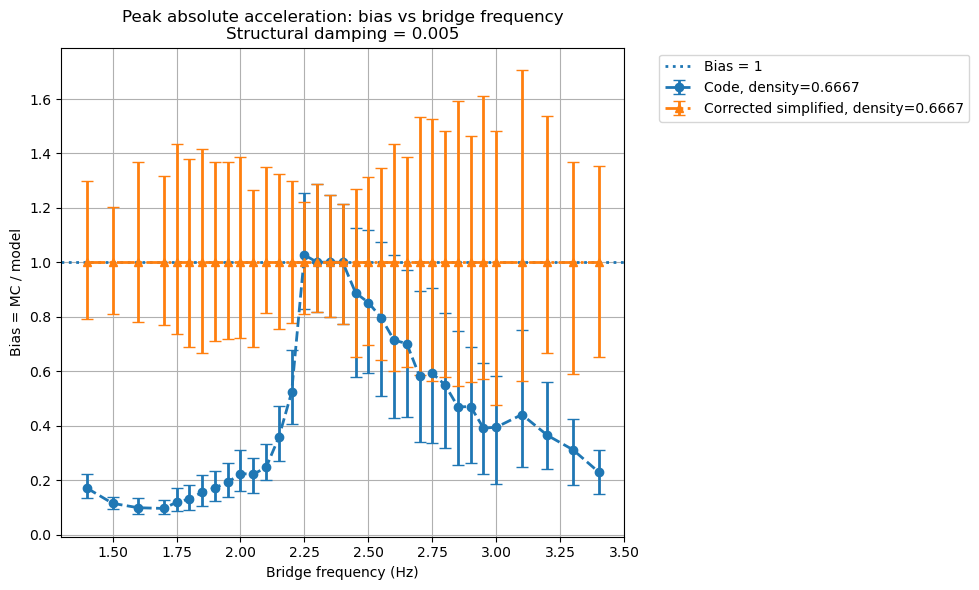

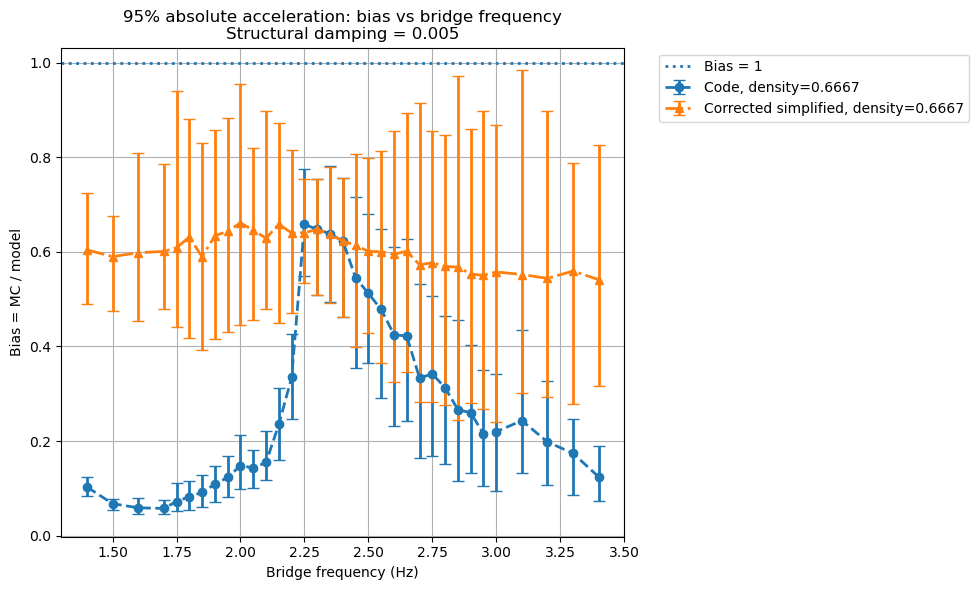

In [6]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.6667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.6667_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.6667_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.8333
----------------------------------------------------------------------
Target density   = 0.8333
Actual density   = 0.8300
Total peds       = 83
Tocity, Outcity  = 41

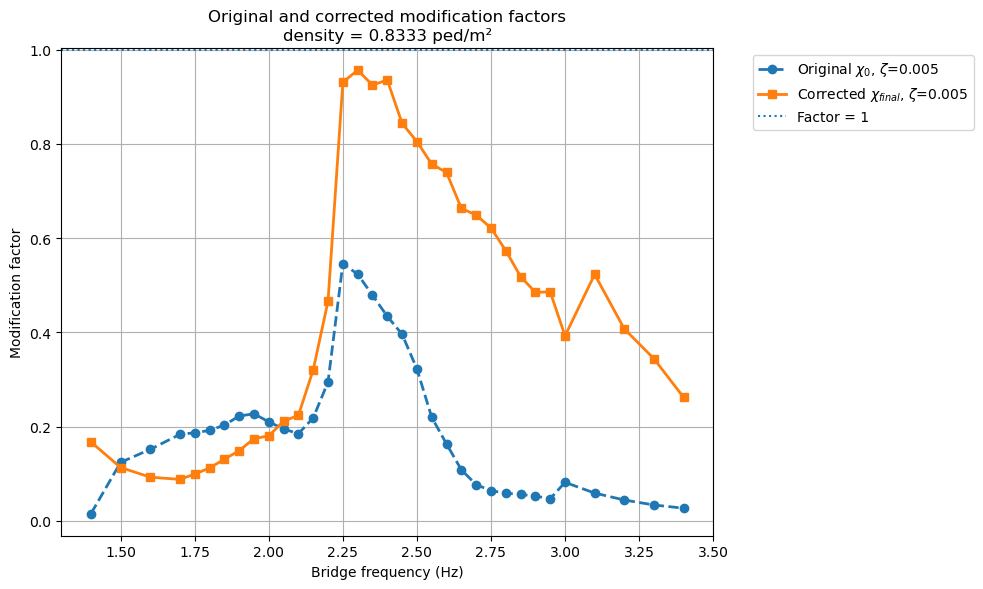

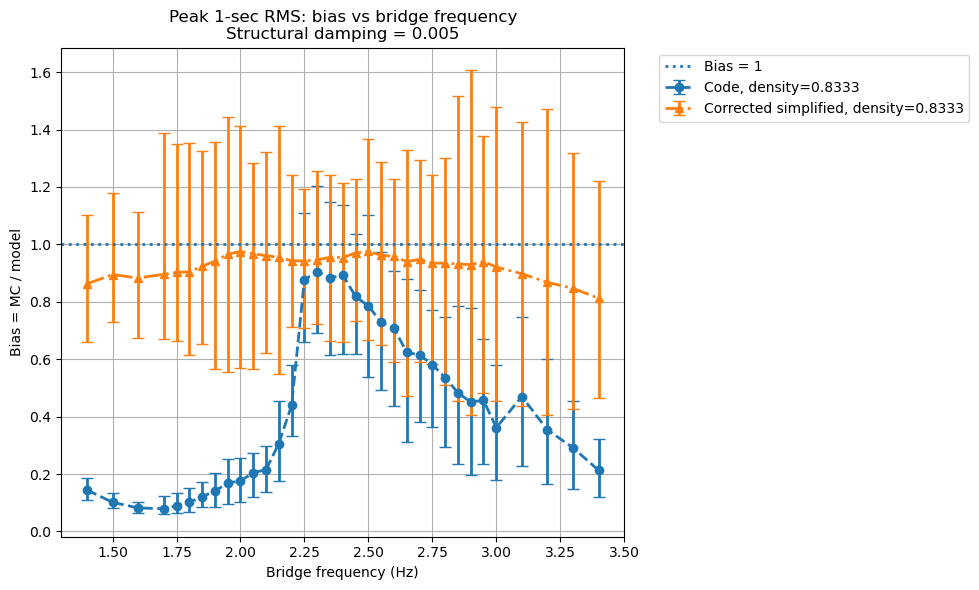

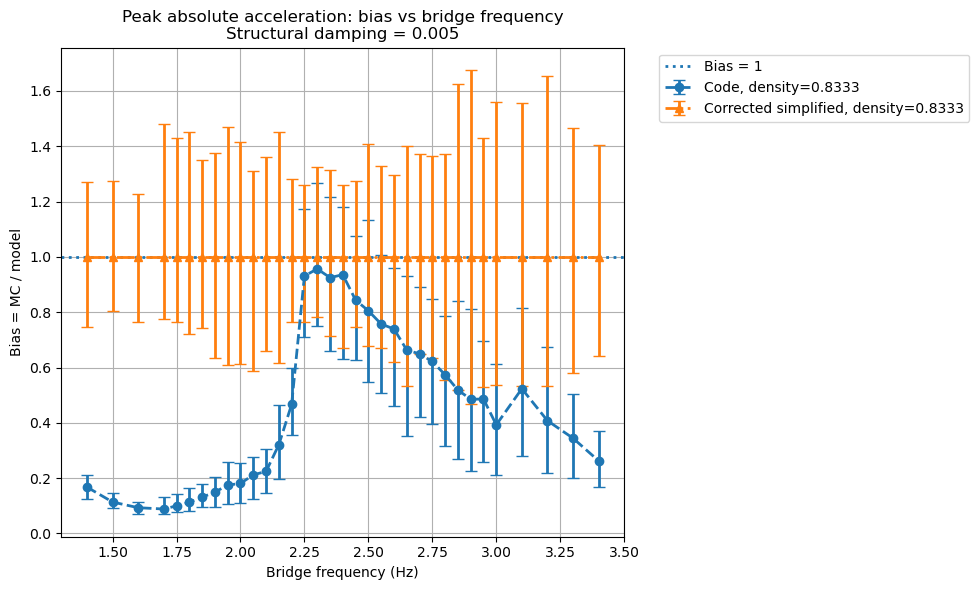

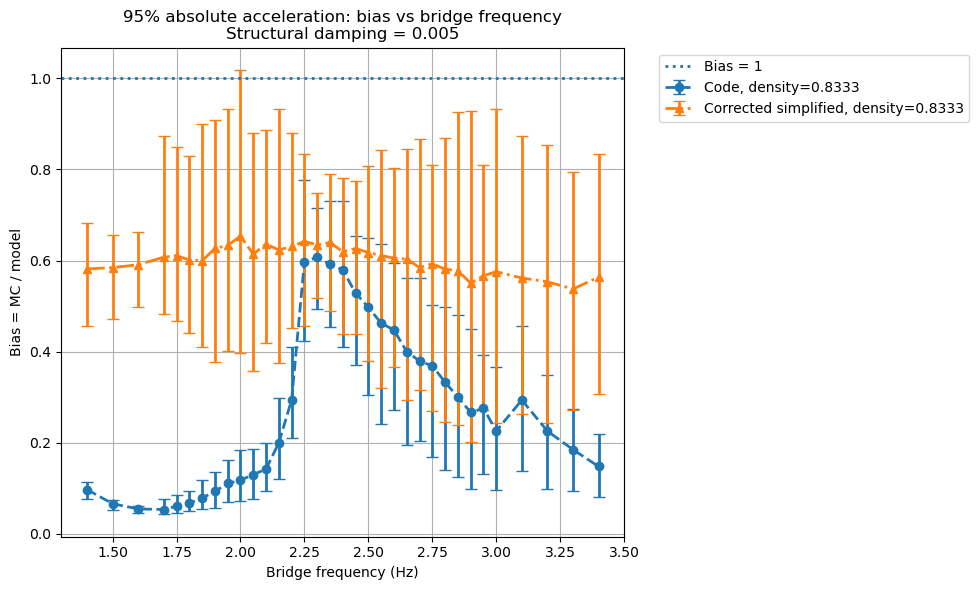

In [1]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.8333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.8333_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density0.8333_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 1.0000
----------------------------------------------------------------------
Target density   = 1.0000
Actual density   = 1.0000
Total peds       = 100
Tocity, Outcity  = 5

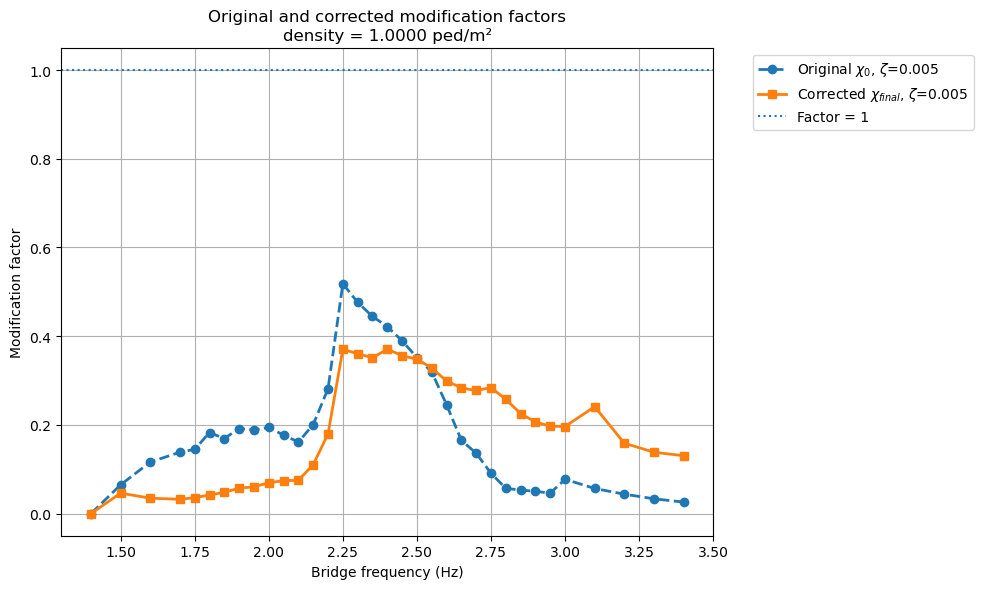

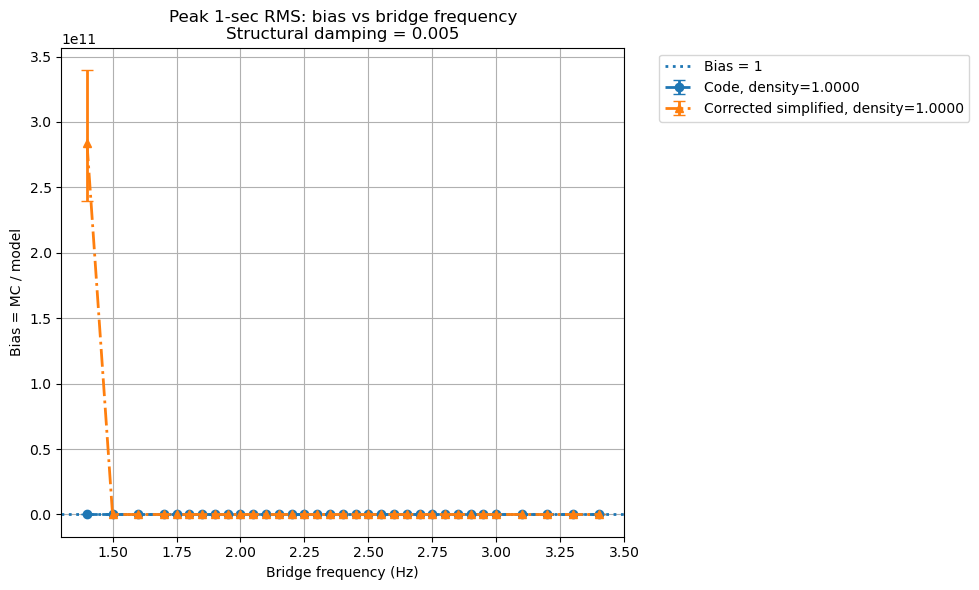

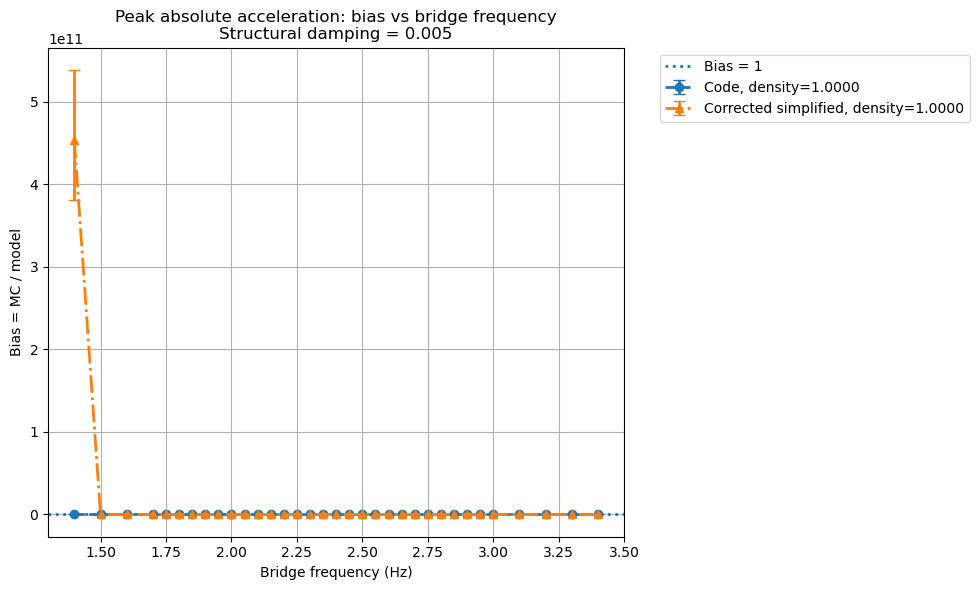

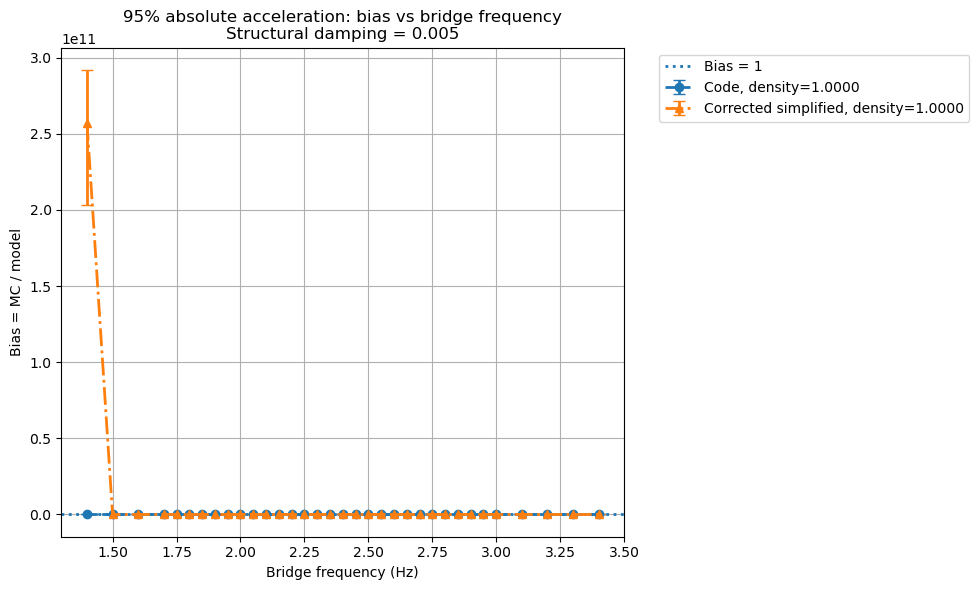

In [2]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.005]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [1.0000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density1.0000_damping0.005_0S_bias_summary.pkl"
    #convergence_pkl = "density1.0000_damping0.005_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.0333
----------------------------------------------------------------------
Target density   = 0.0333
Actual density   = 0.0300
Total peds       = 3
Tocity, Outcity  = 1, 

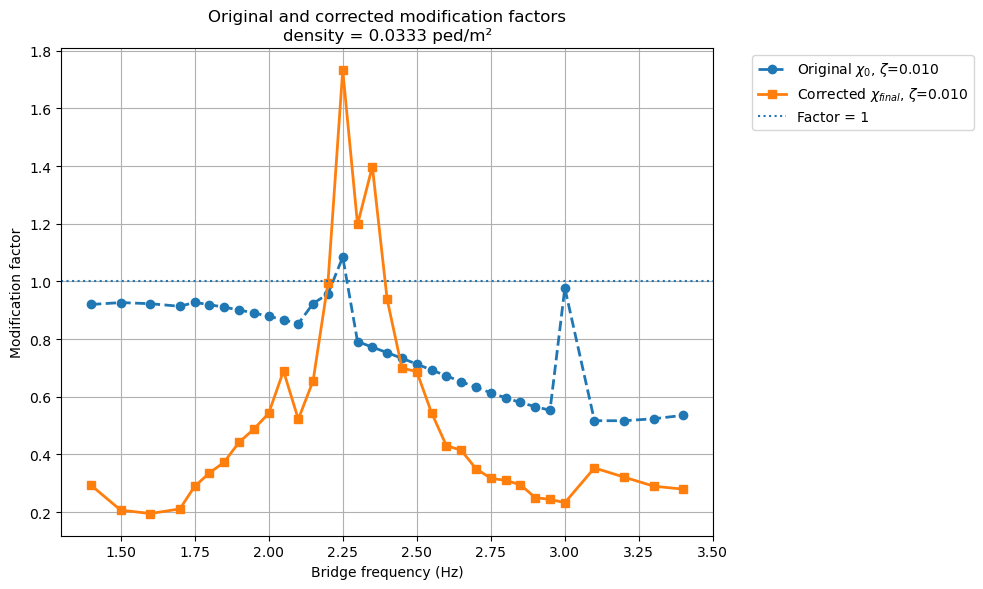

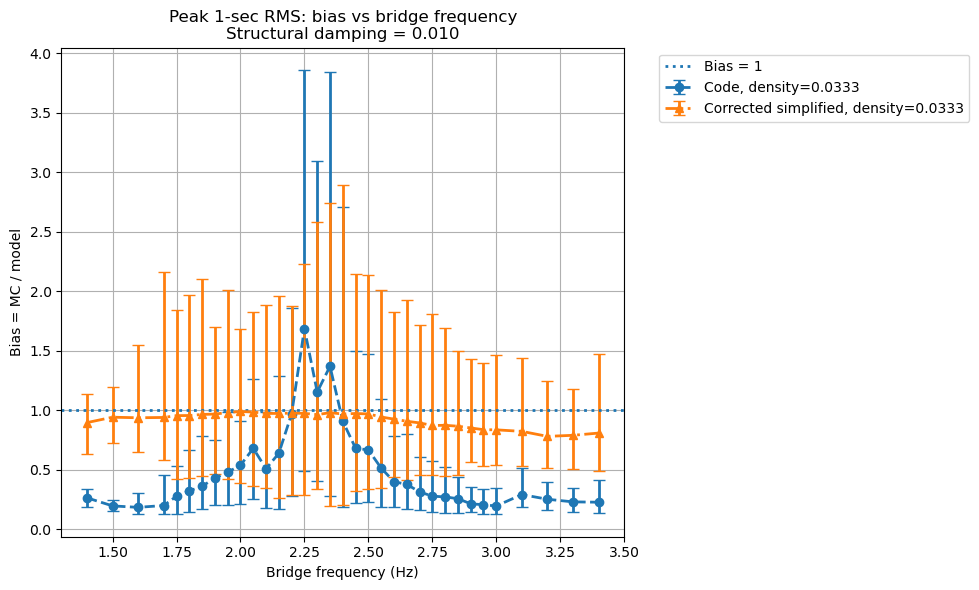

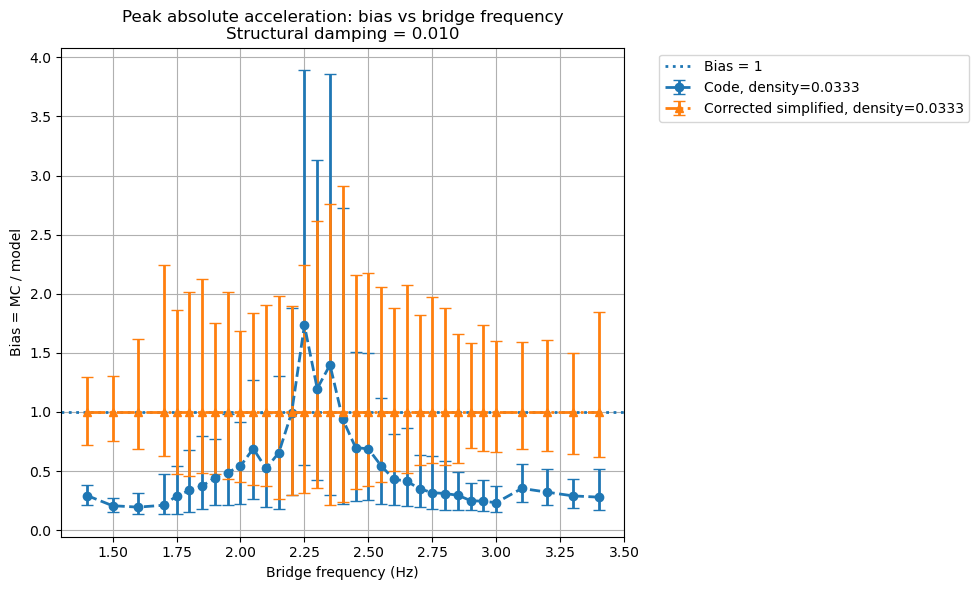

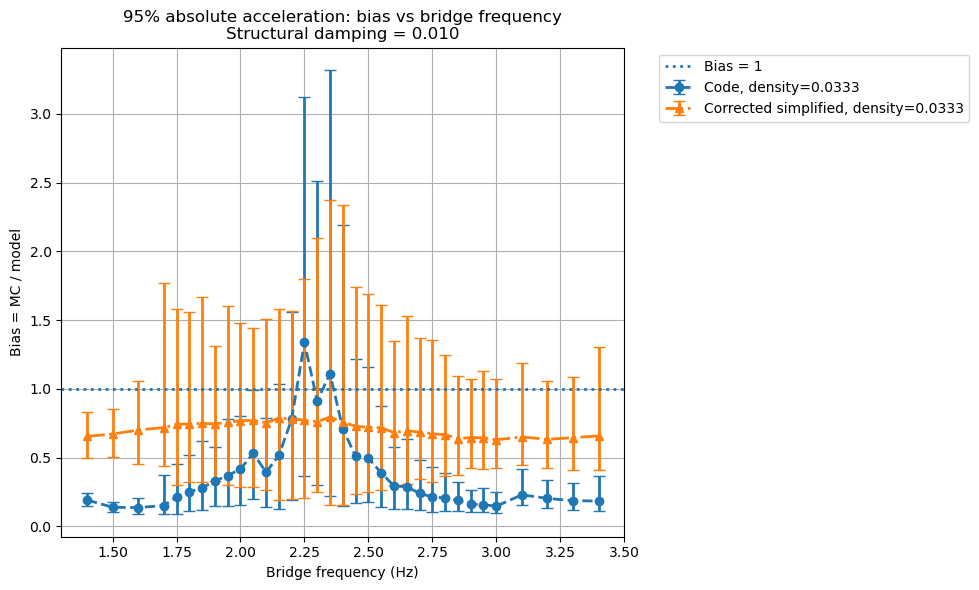

In [3]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.0333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.0333_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.0333_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.1667
----------------------------------------------------------------------
Target density   = 0.1667
Actual density   = 0.1700
Total peds       = 17
Tocity, Outcity  = 8,

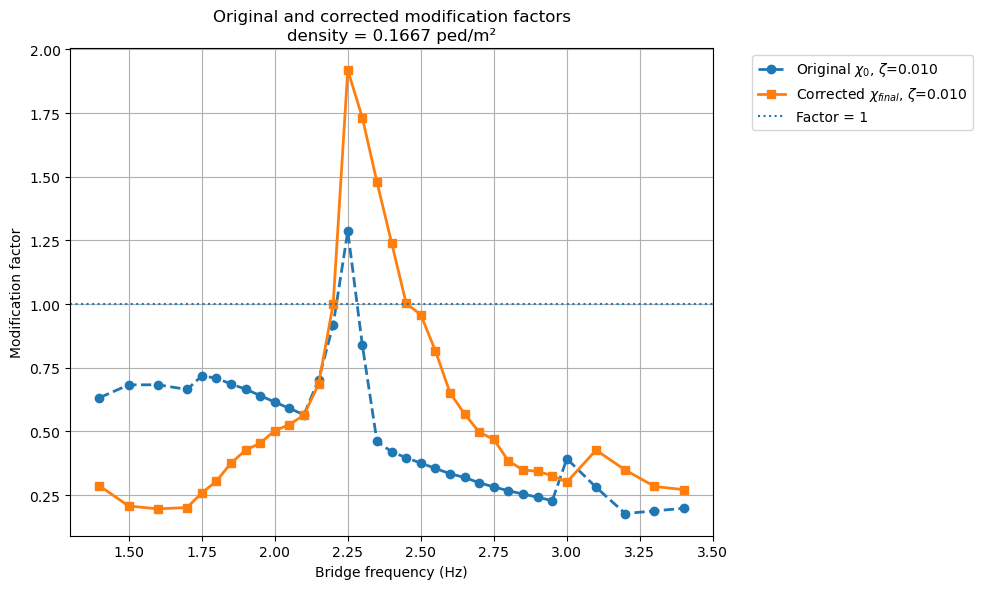

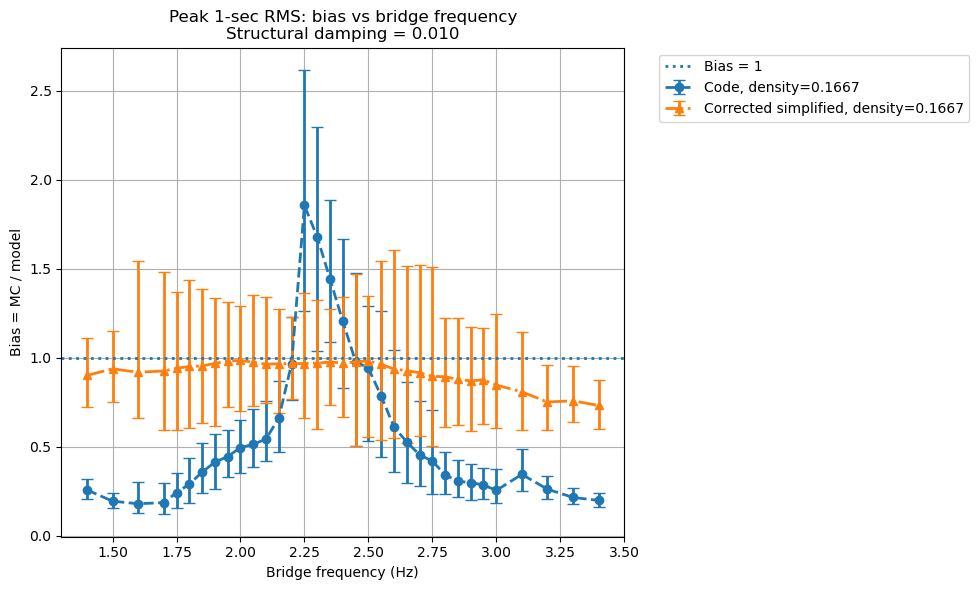

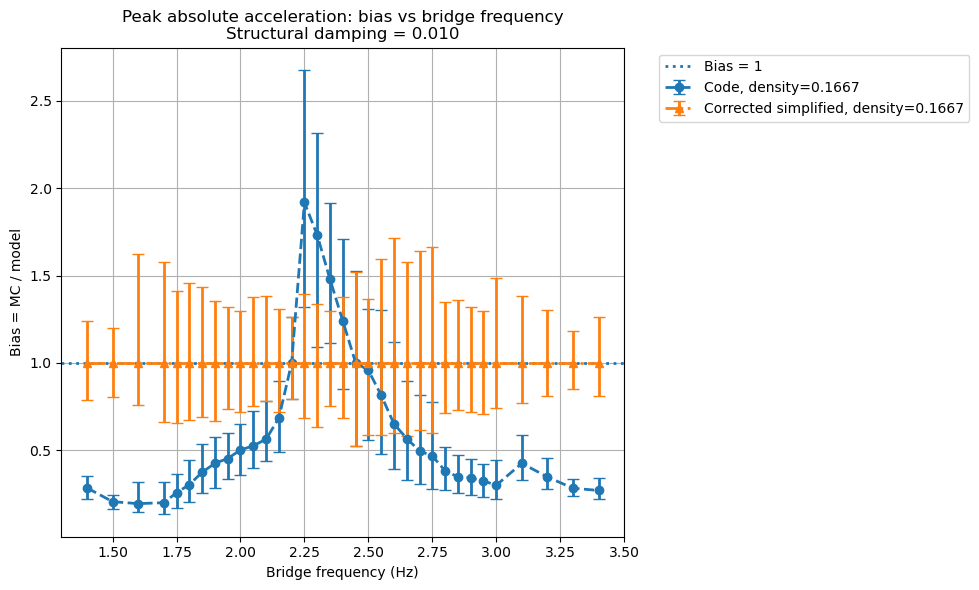

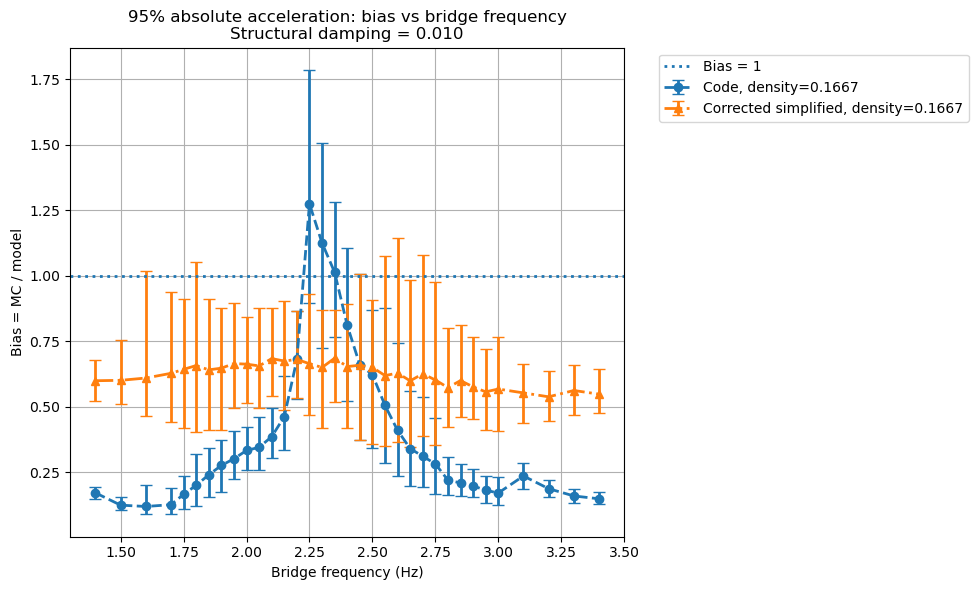

In [4]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.1667_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.1667_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.3333
----------------------------------------------------------------------
Target density   = 0.3333
Actual density   = 0.3300
Total peds       = 33
Tocity, Outcity  = 16

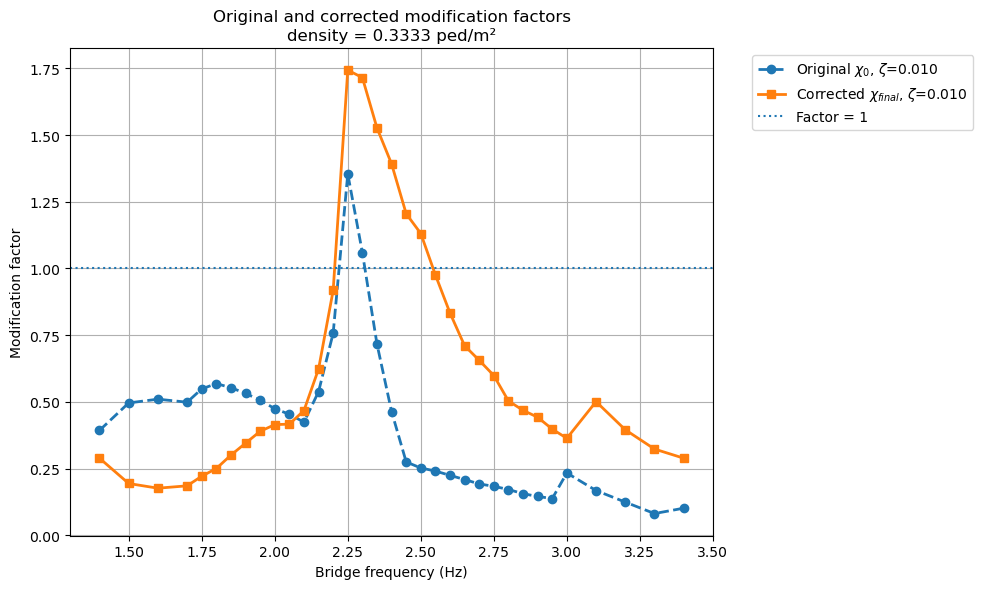

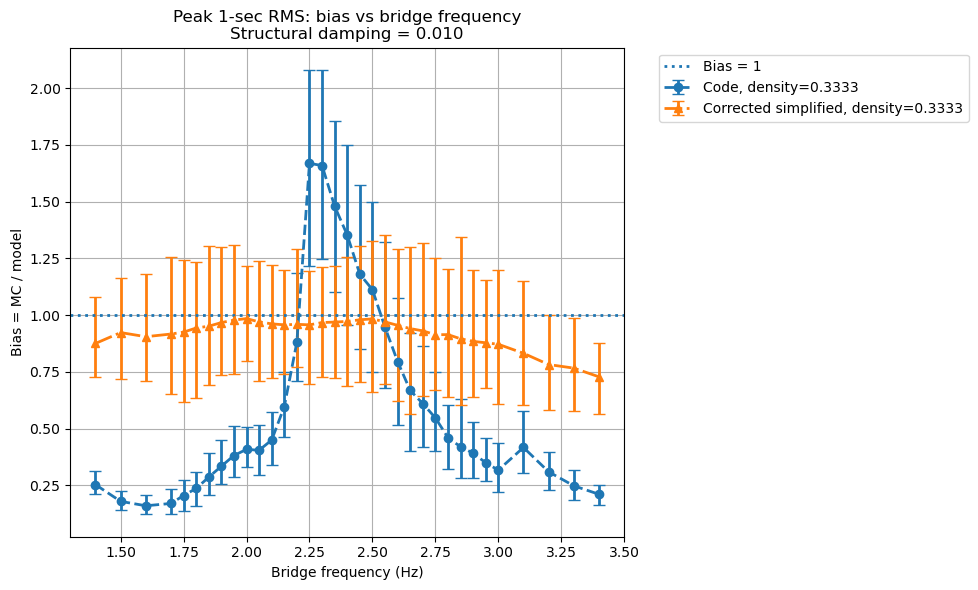

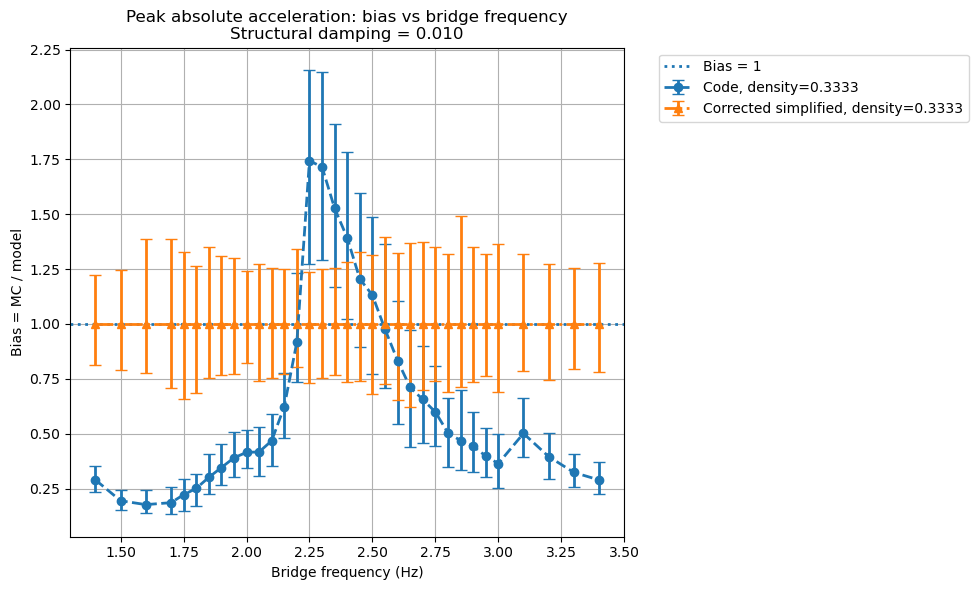

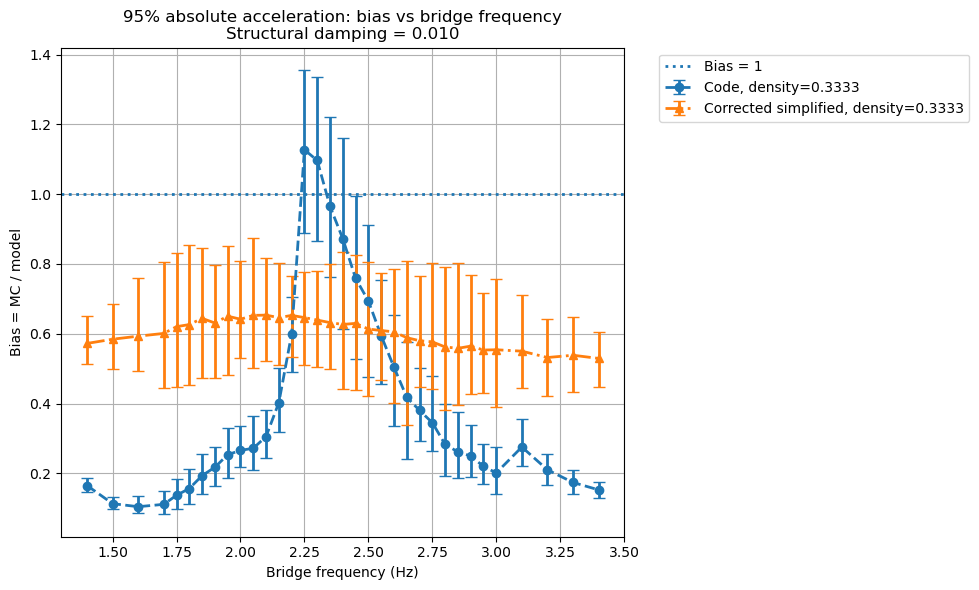

In [5]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.3333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.3333_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.3333_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.5000
----------------------------------------------------------------------
Target density   = 0.5000
Actual density   = 0.5000
Total peds       = 50
Tocity, Outcity  = 25

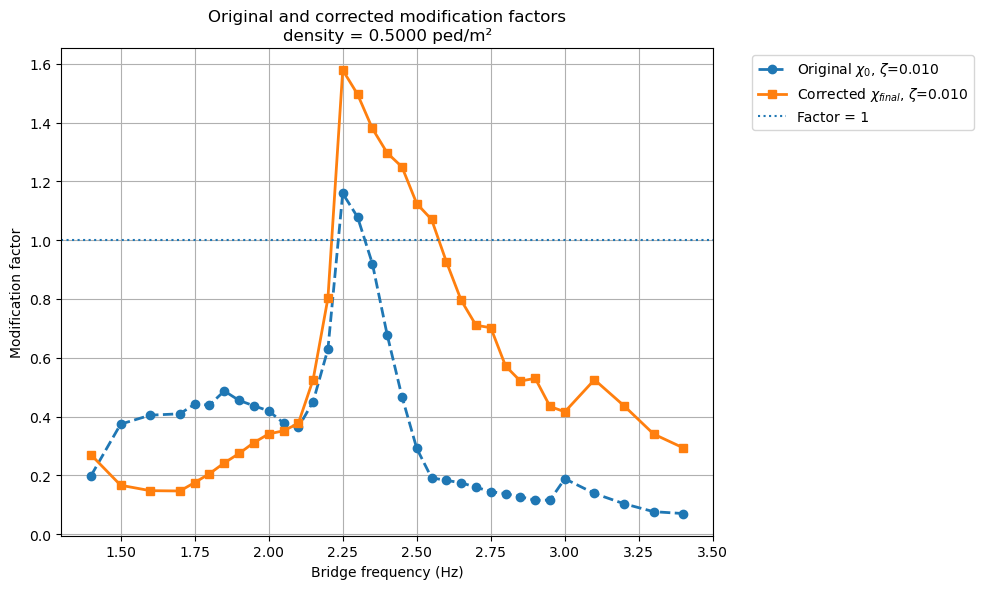

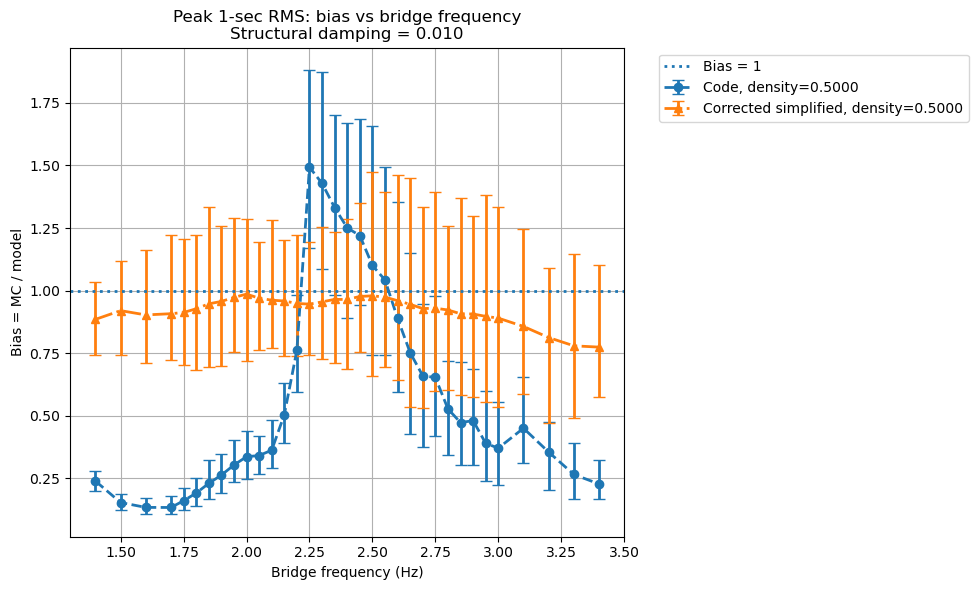

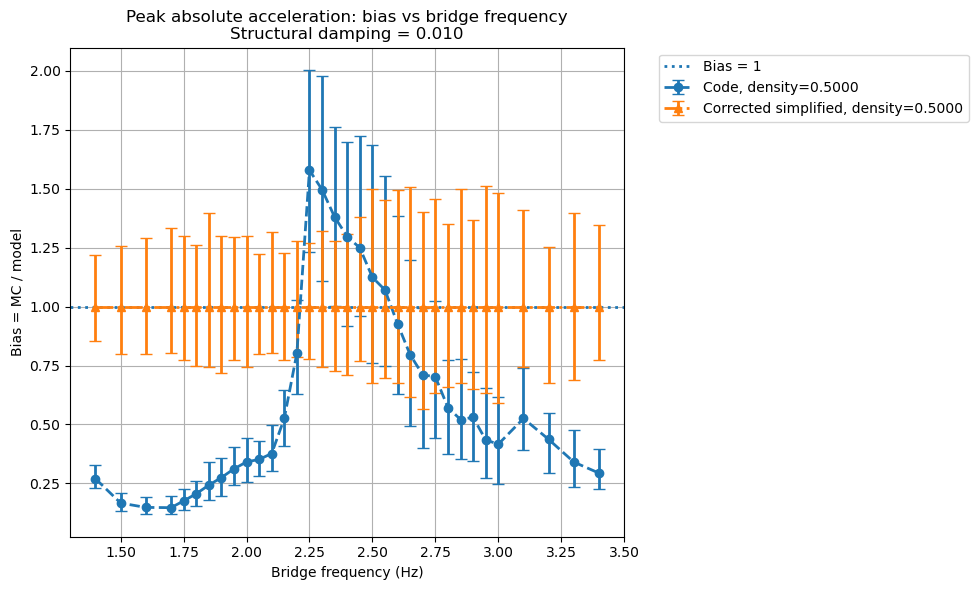

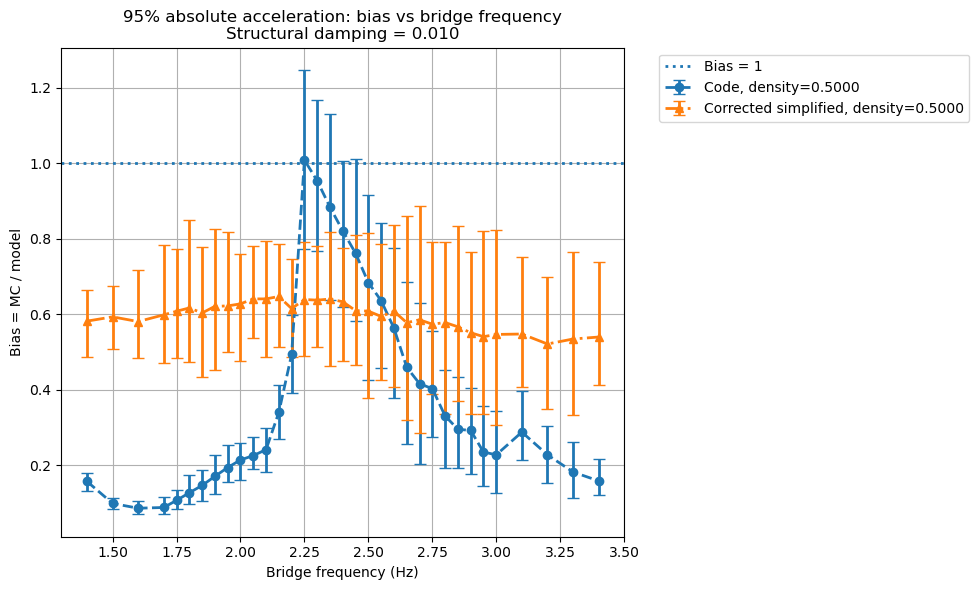

In [6]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.5000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.5000_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.5000_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.6667
----------------------------------------------------------------------
Target density   = 0.6667
Actual density   = 0.6700
Total peds       = 67
Tocity, Outcity  = 33

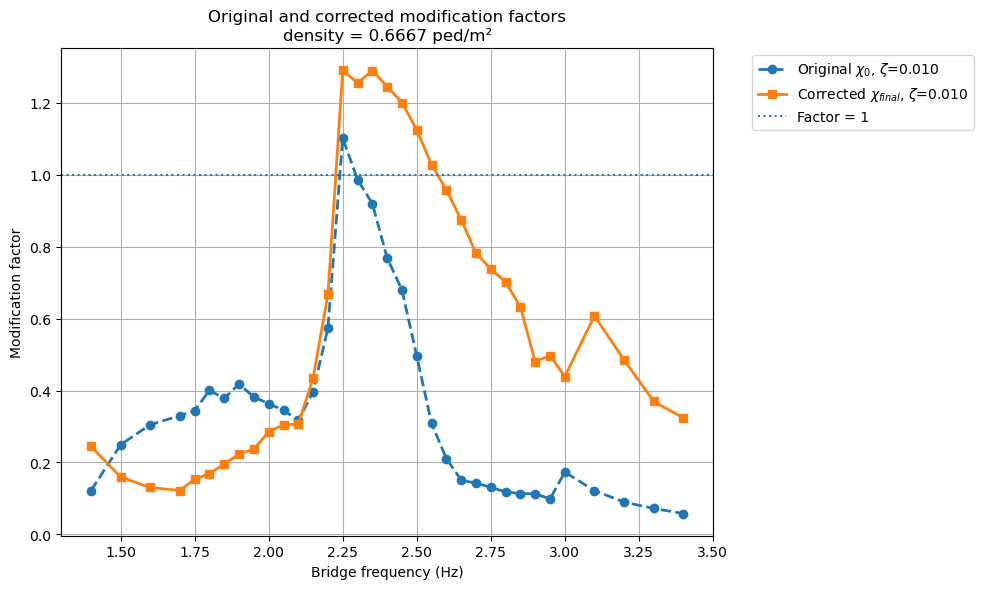

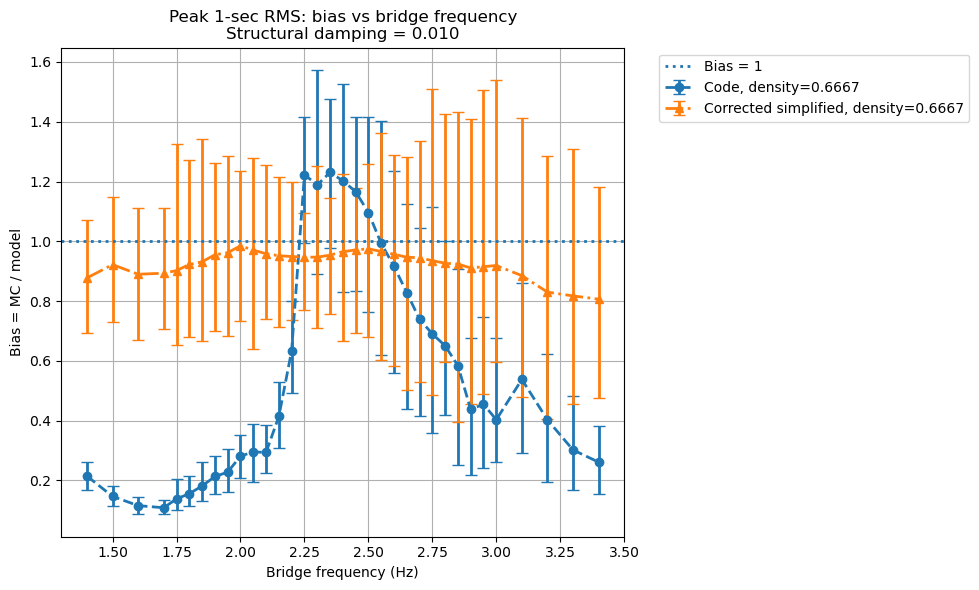

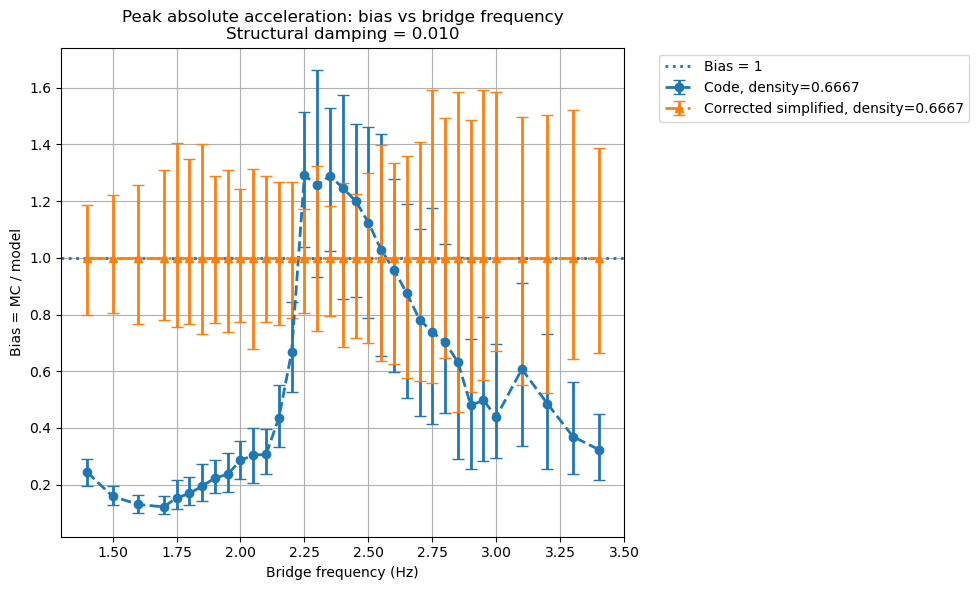

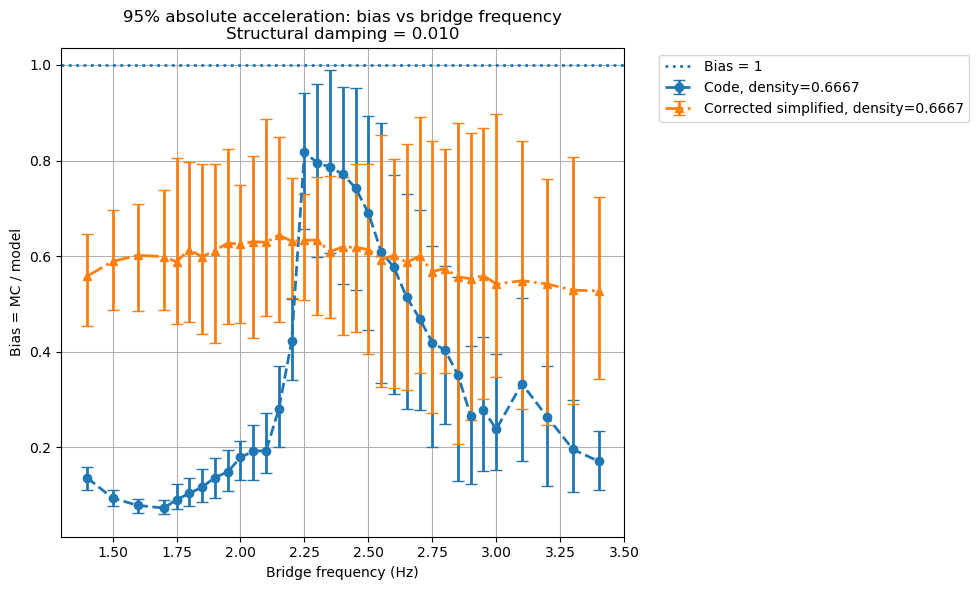

In [7]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.6667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.6667_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.6667_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.8333
----------------------------------------------------------------------
Target density   = 0.8333
Actual density   = 0.8300
Total peds       = 83
Tocity, Outcity  = 41

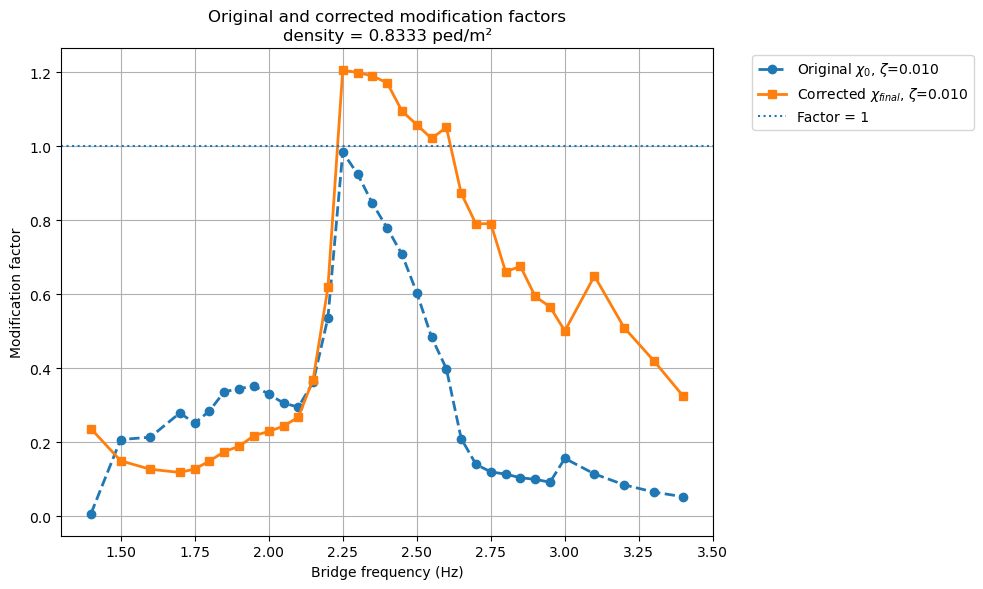

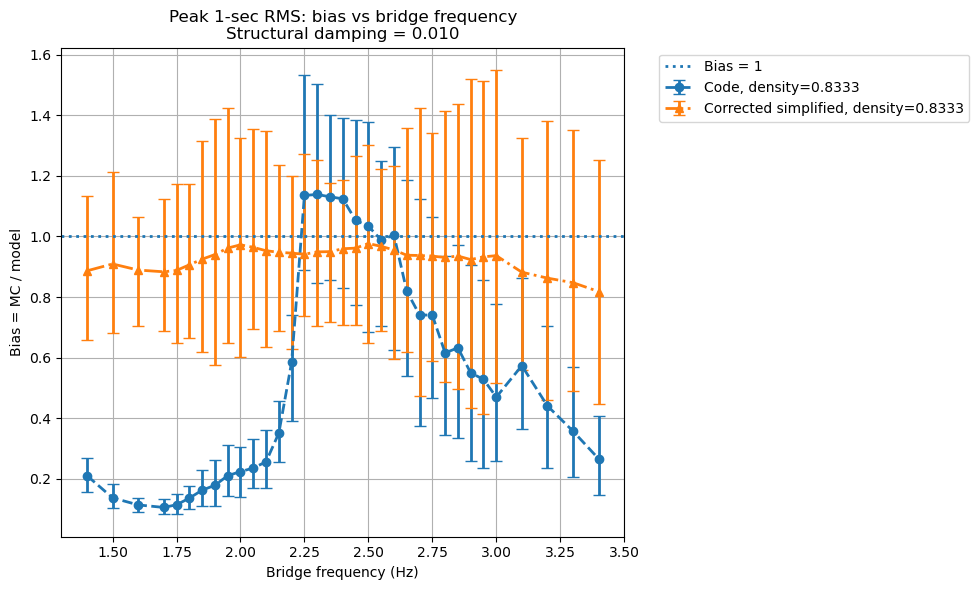

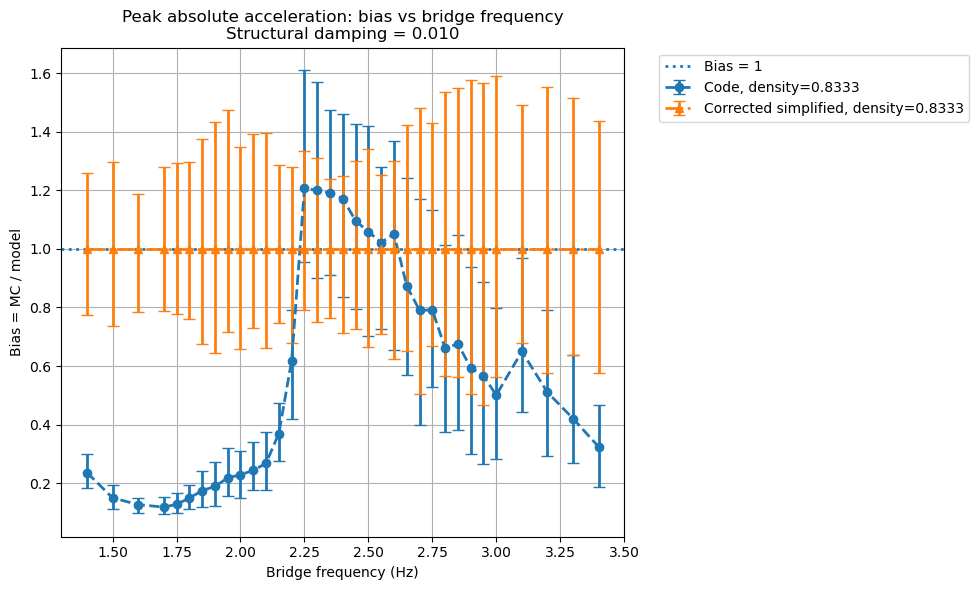

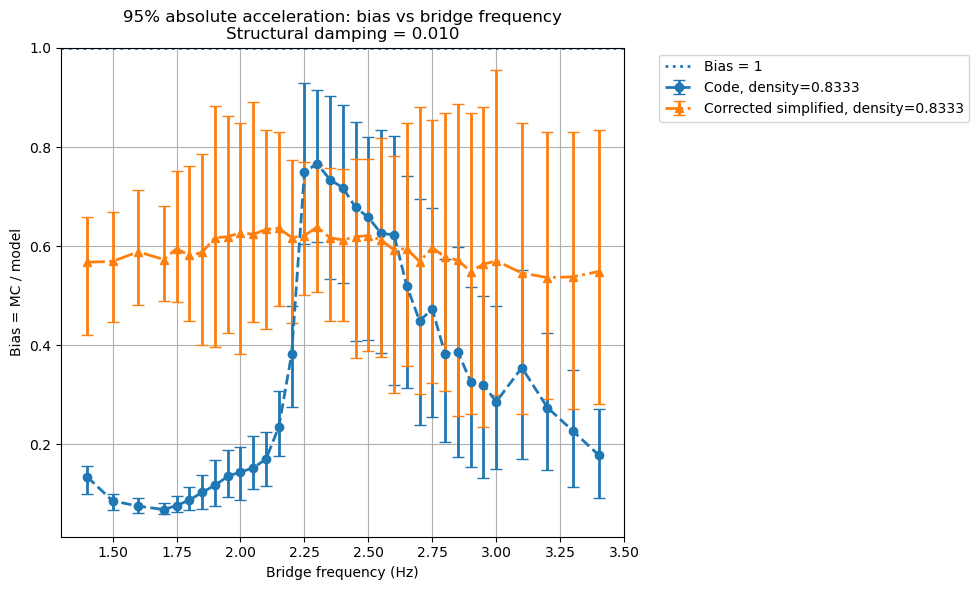

In [8]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.8333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.8333_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density0.8333_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0100
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 1.0000
----------------------------------------------------------------------
Target density   = 1.0000
Actual density   = 1.0000
Total peds       = 100
Tocity, Outcity  = 5

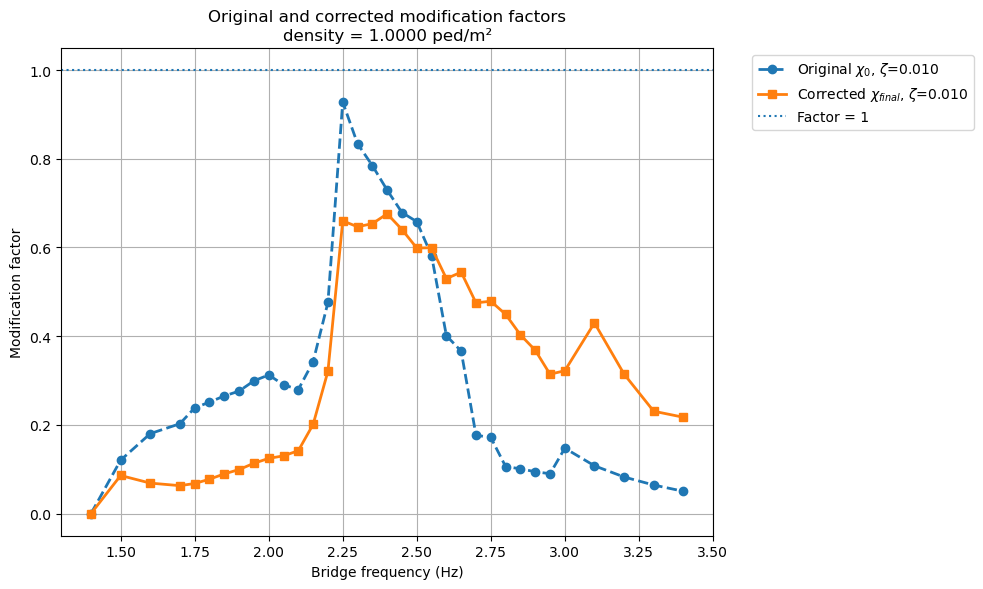

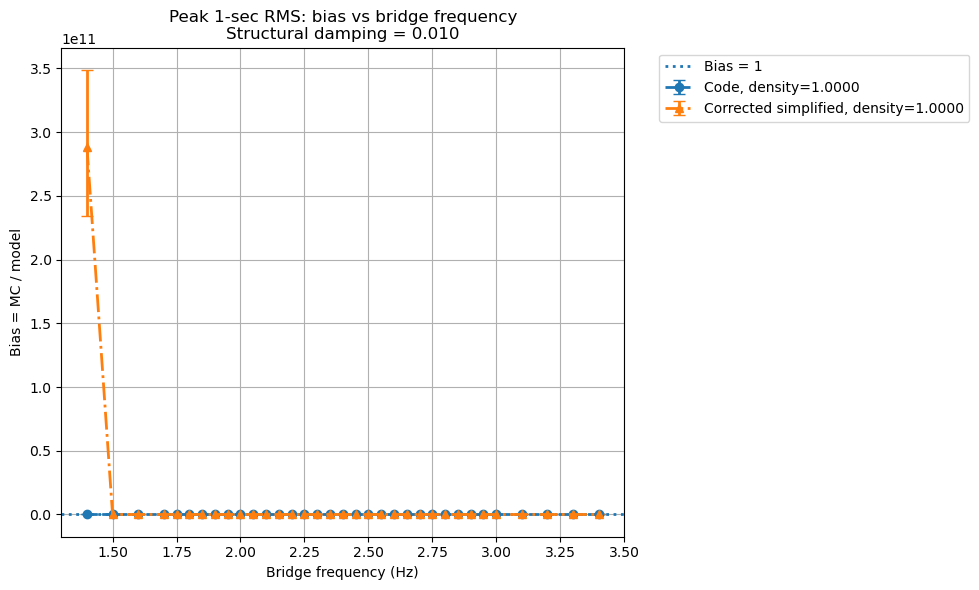

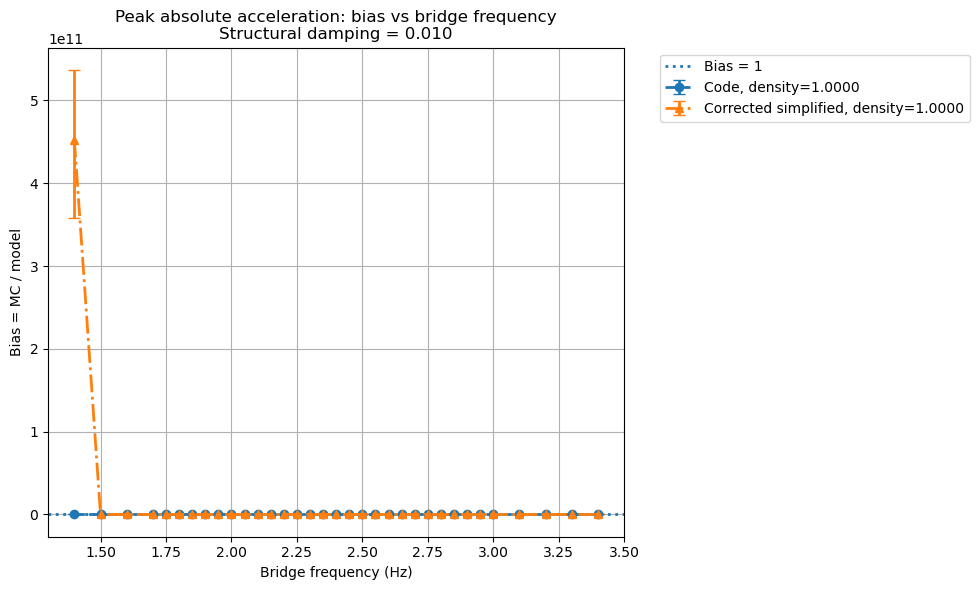

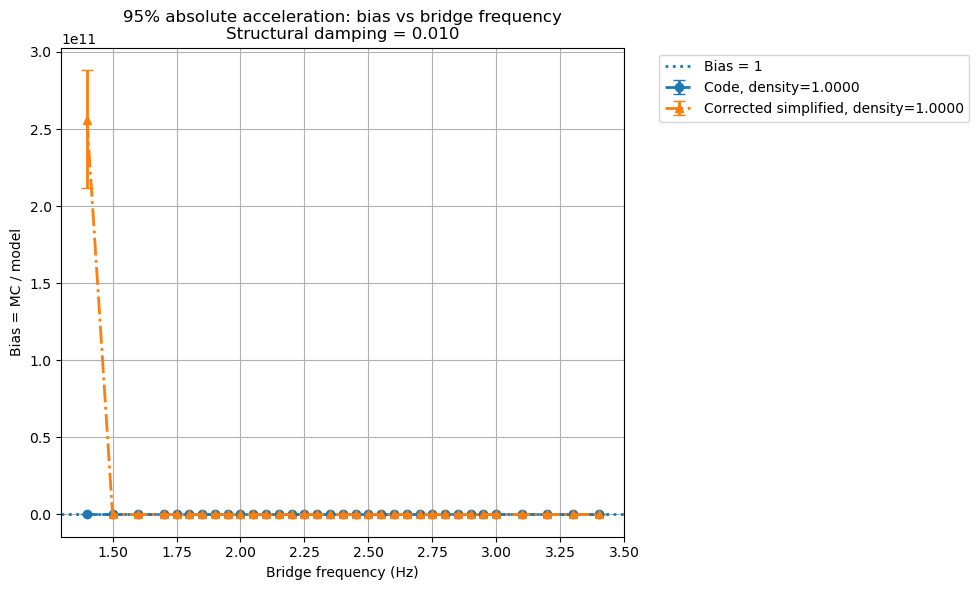

In [9]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.010]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [1.0000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density1.0000_damping0.010_0S_bias_summary.pkl"
    #convergence_pkl = "density1.0000_damping0.010_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.0333
----------------------------------------------------------------------
Target density   = 0.0333
Actual density   = 0.0300
Total peds       = 3
Tocity, Outcity  = 1, 

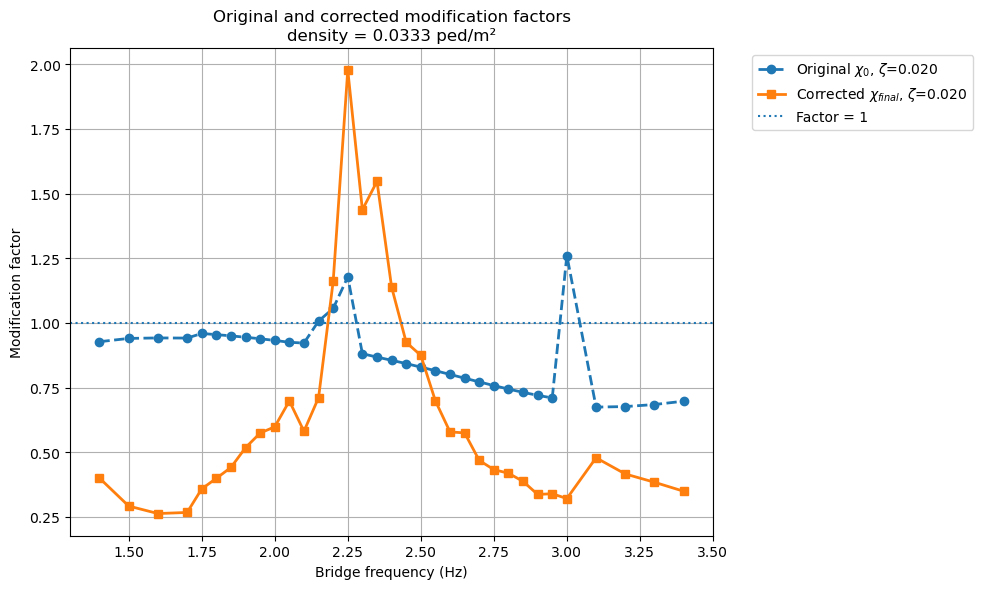

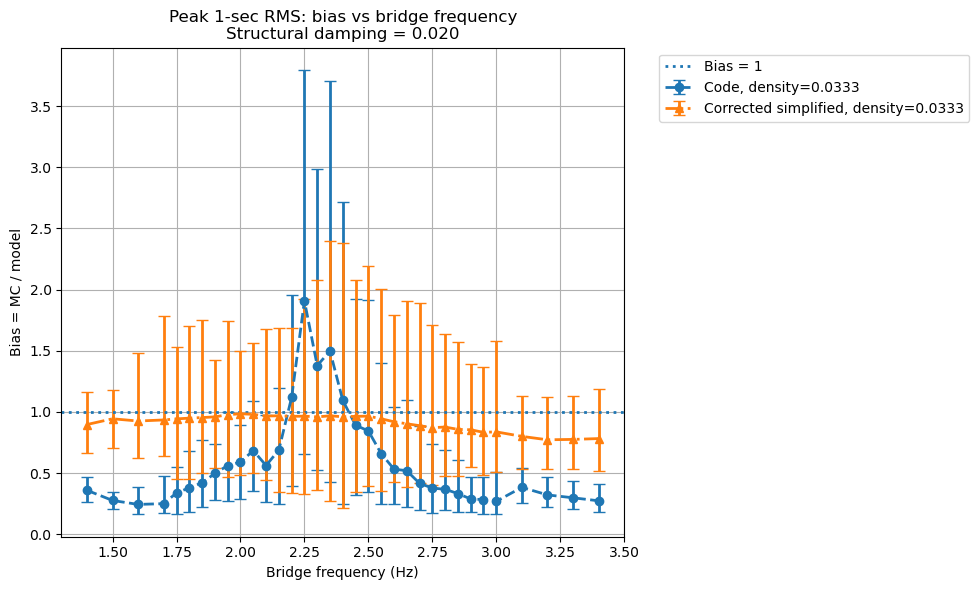

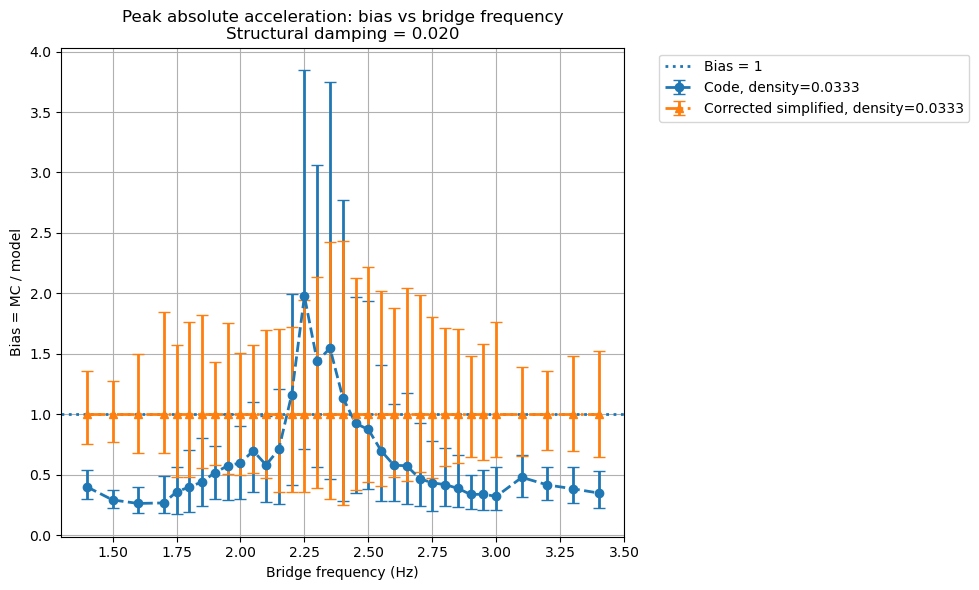

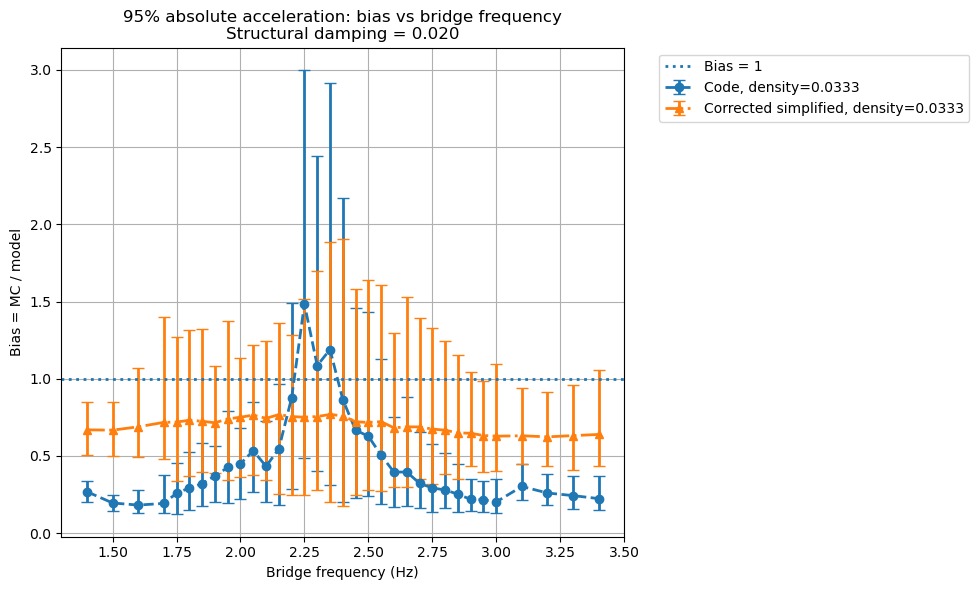

In [10]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.0333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.0333_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.0333_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.1667
----------------------------------------------------------------------
Target density   = 0.1667
Actual density   = 0.1700
Total peds       = 17
Tocity, Outcity  = 8,

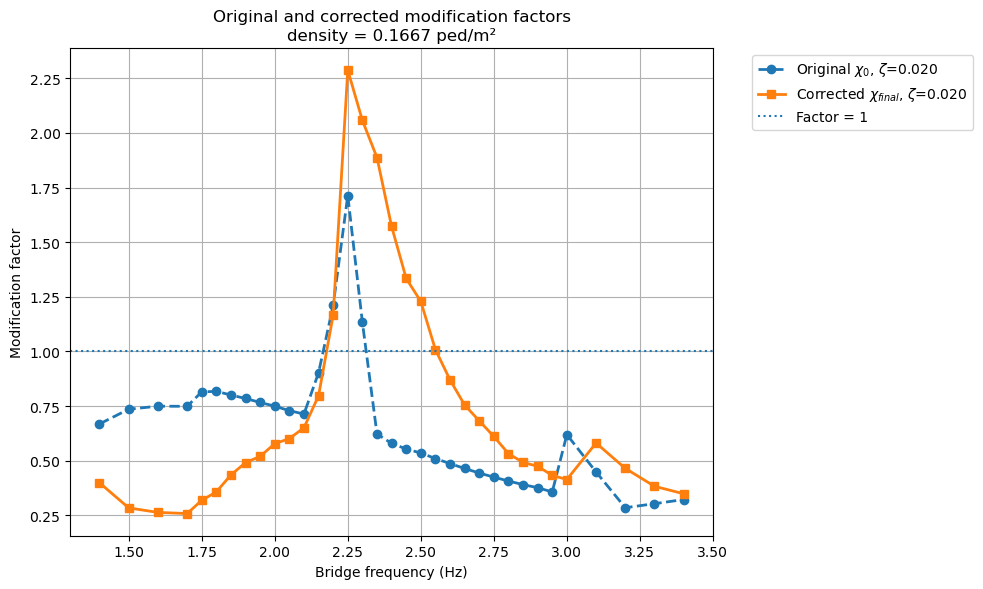

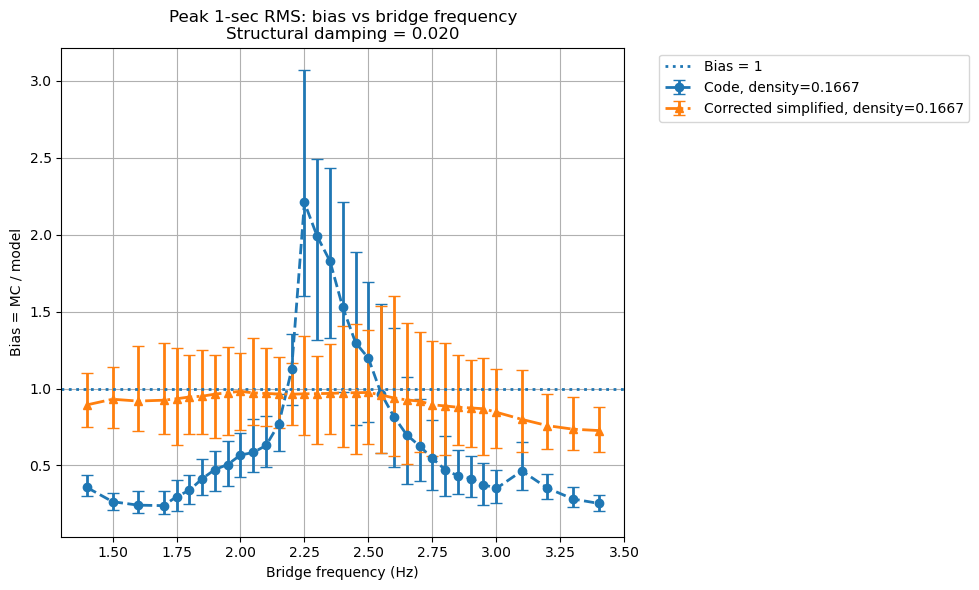

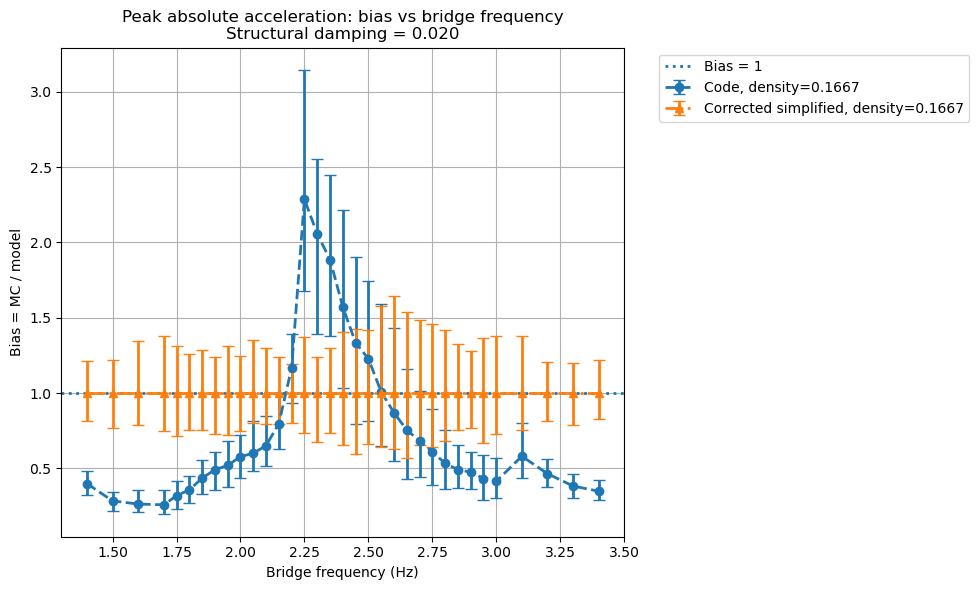

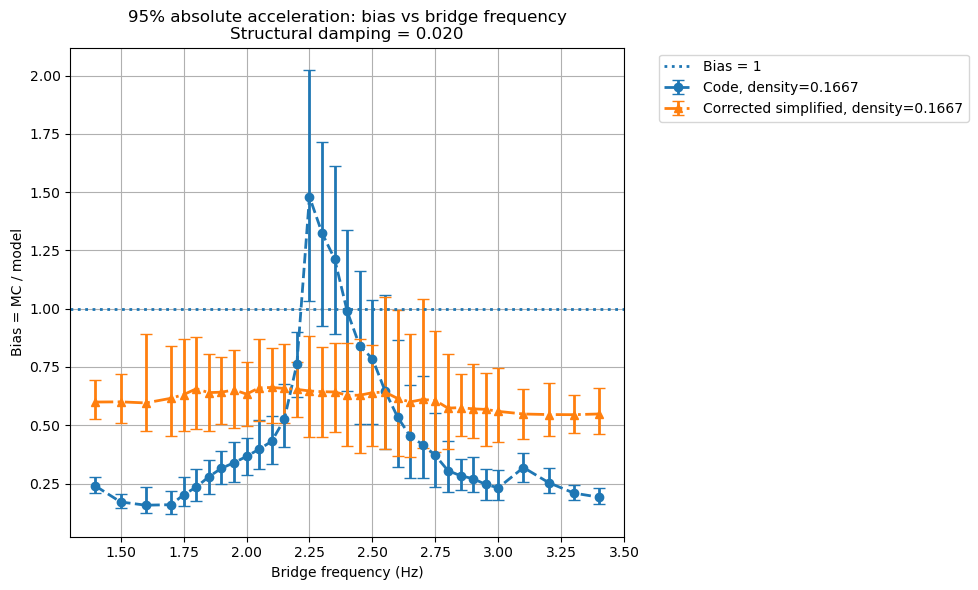

In [11]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.1667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.1667_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.1667_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.3333
----------------------------------------------------------------------
Target density   = 0.3333
Actual density   = 0.3300
Total peds       = 33
Tocity, Outcity  = 16

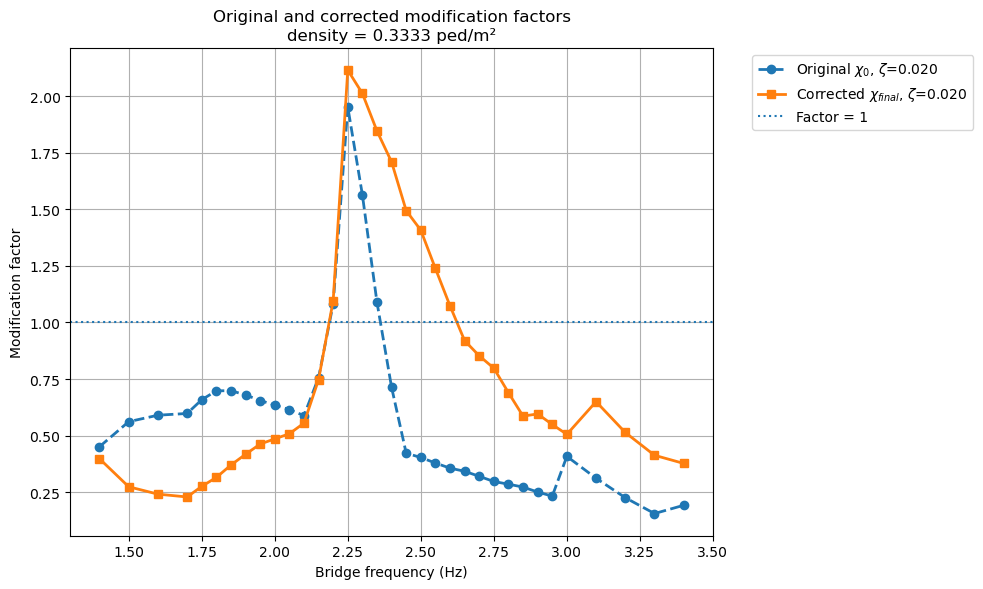

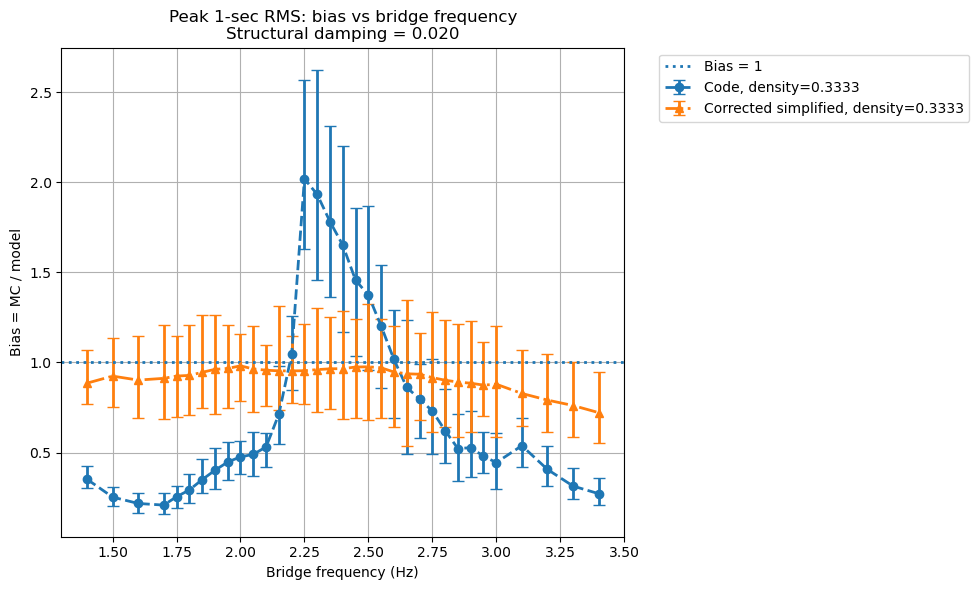

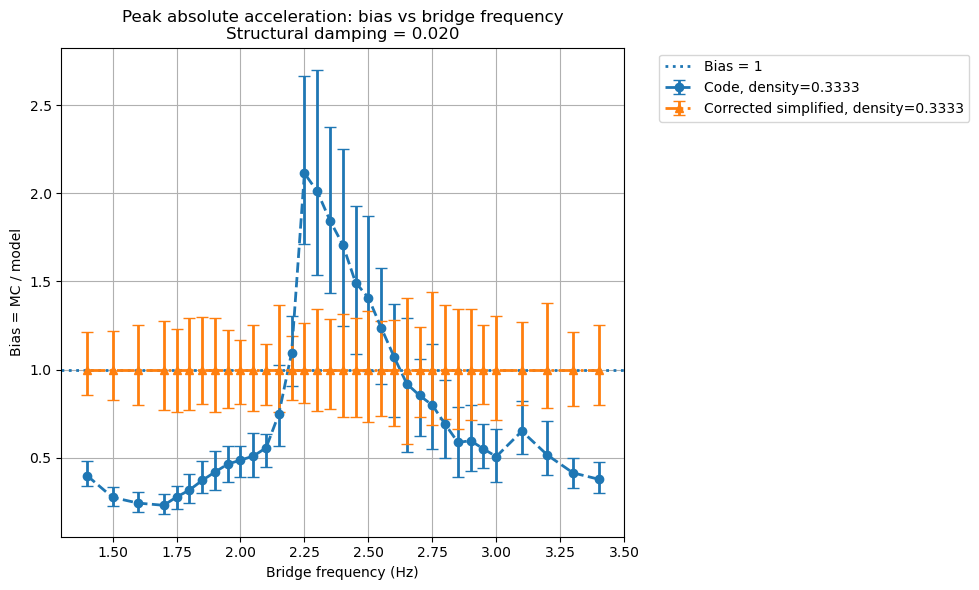

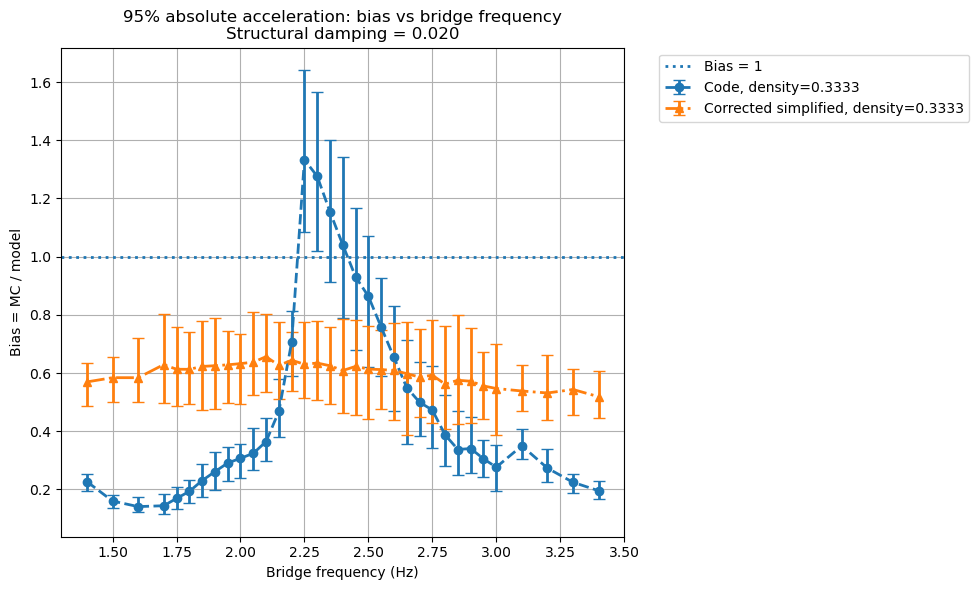

In [12]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.3333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.3333_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.3333_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.5000
----------------------------------------------------------------------
Target density   = 0.5000
Actual density   = 0.5000
Total peds       = 50
Tocity, Outcity  = 25

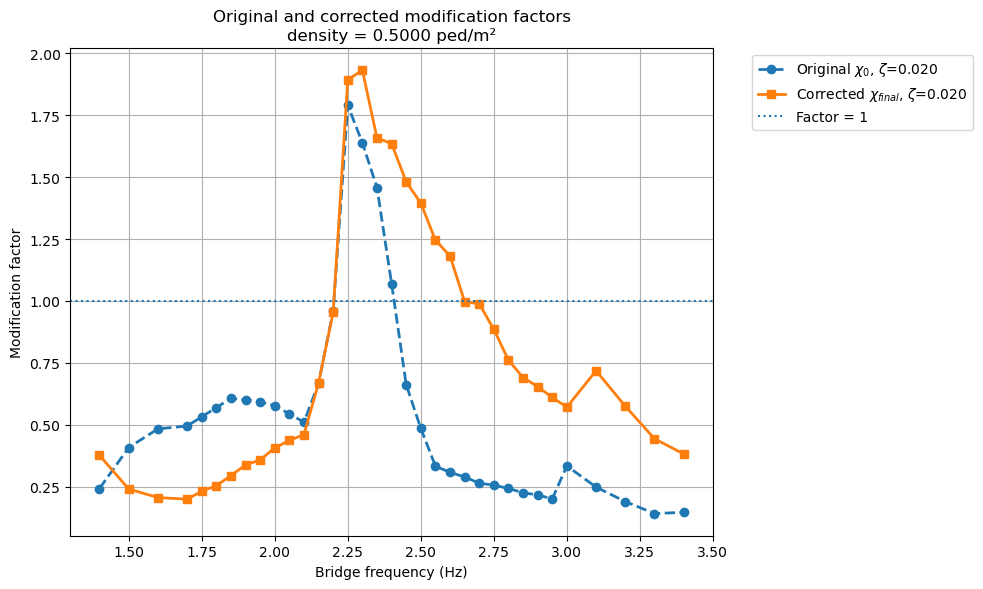

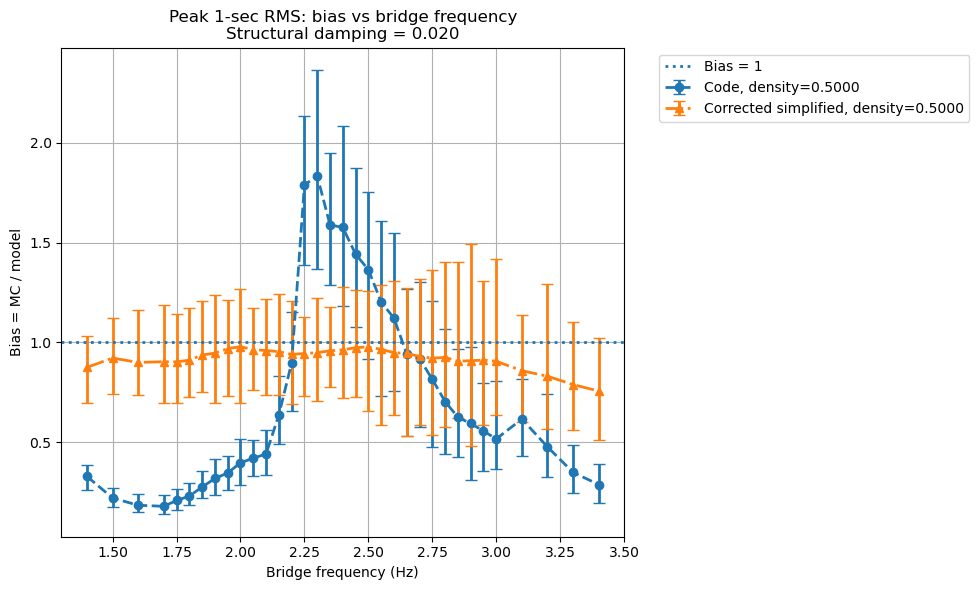

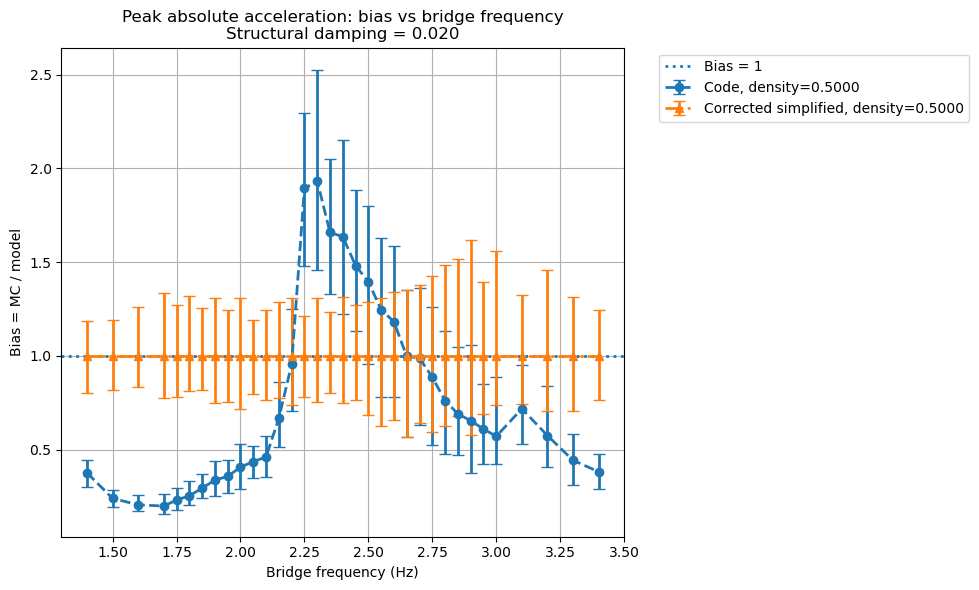

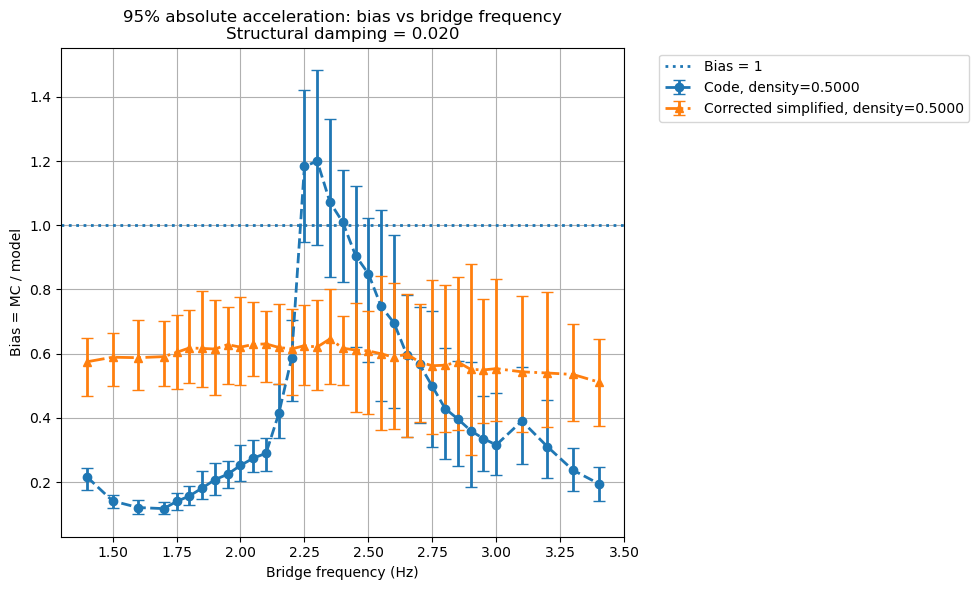

In [13]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.5000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.5000_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.5000_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.6667
----------------------------------------------------------------------
Target density   = 0.6667
Actual density   = 0.6700
Total peds       = 67
Tocity, Outcity  = 33

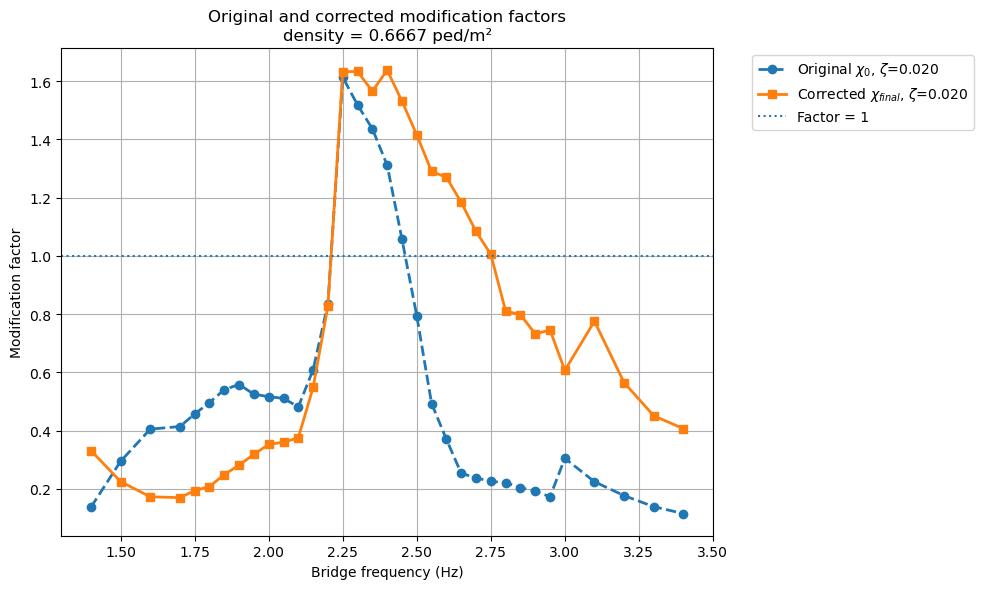

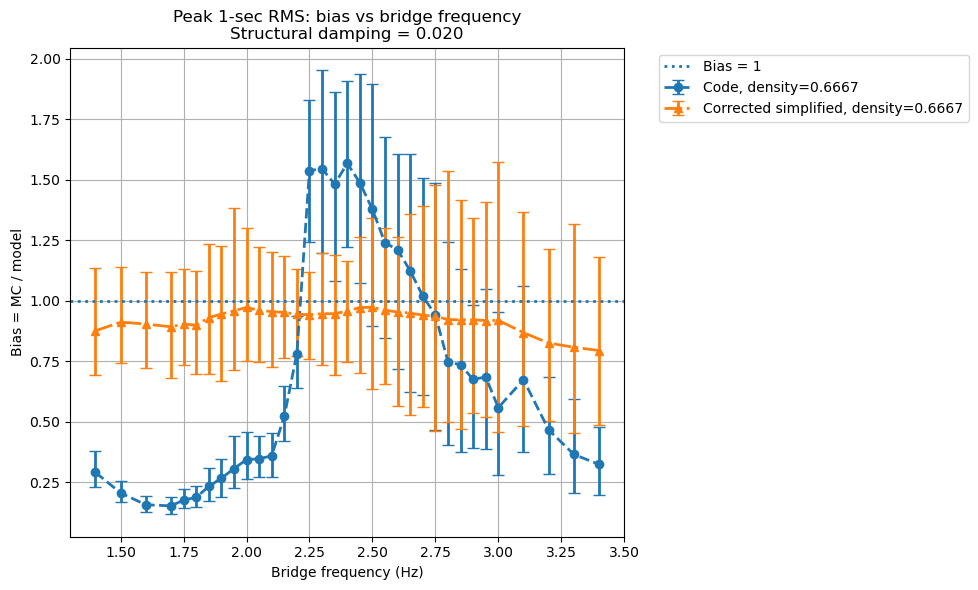

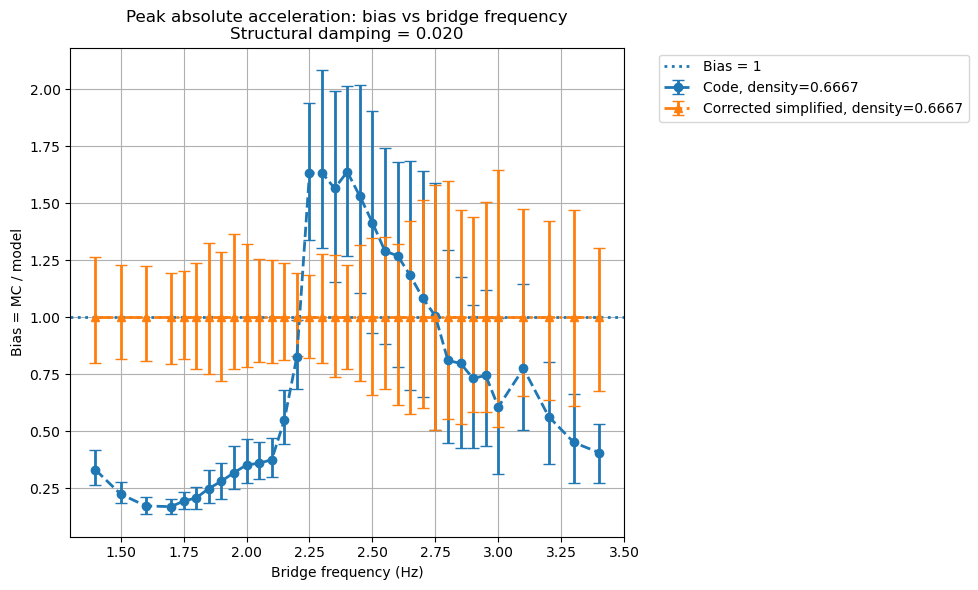

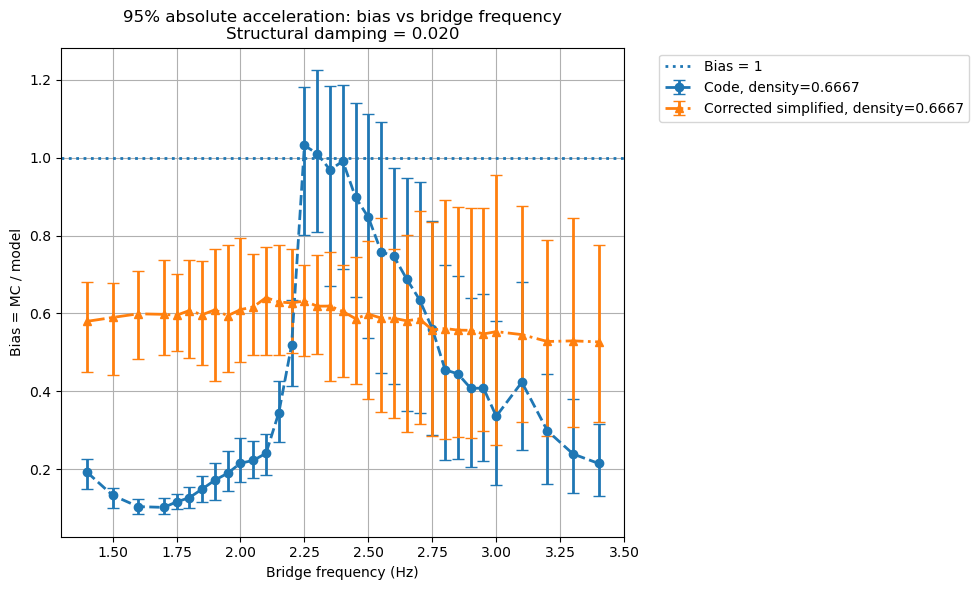

In [14]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.6667]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.6667_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.6667_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 0.8333
----------------------------------------------------------------------
Target density   = 0.8333
Actual density   = 0.8300
Total peds       = 83
Tocity, Outcity  = 41

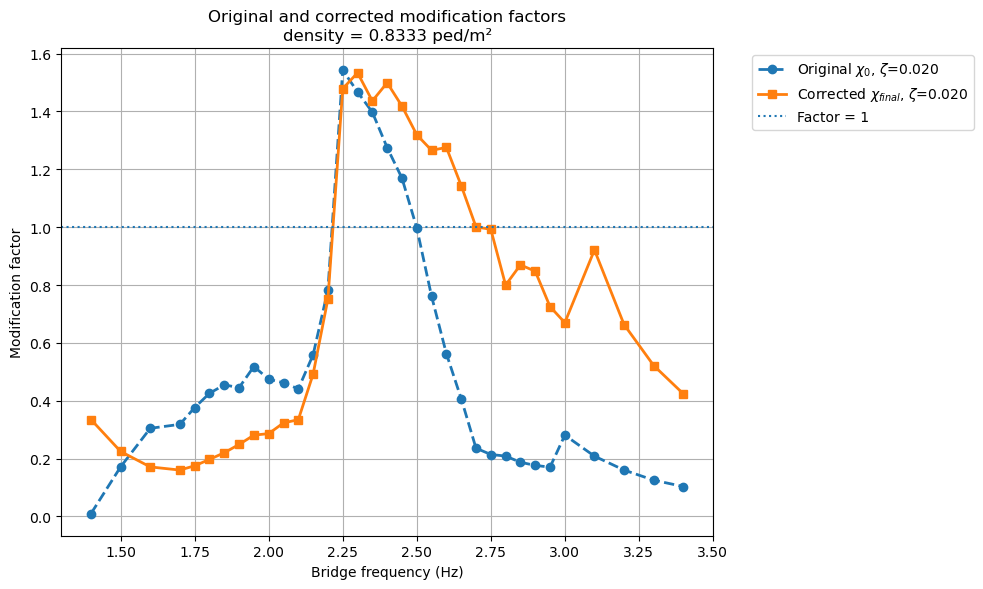

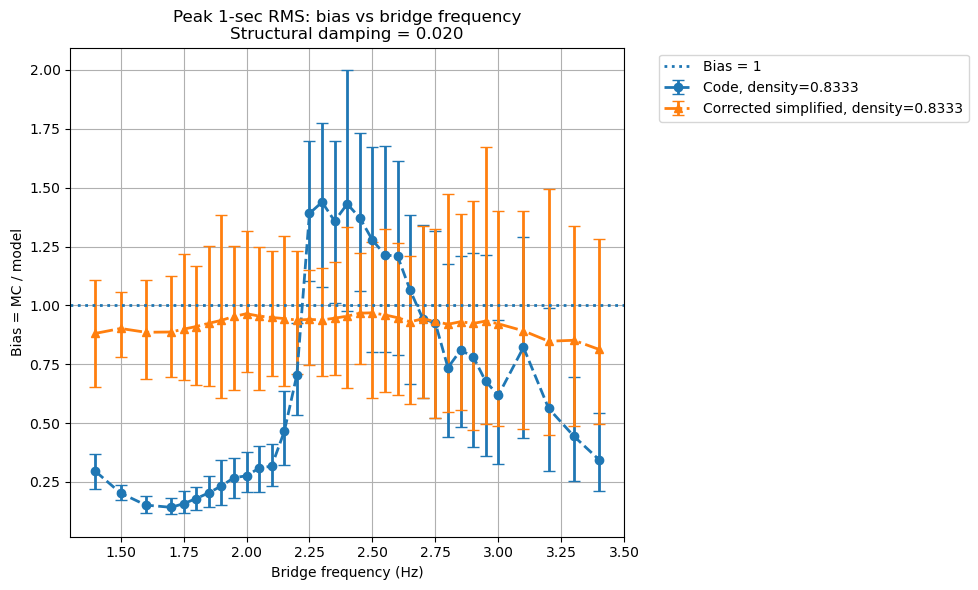

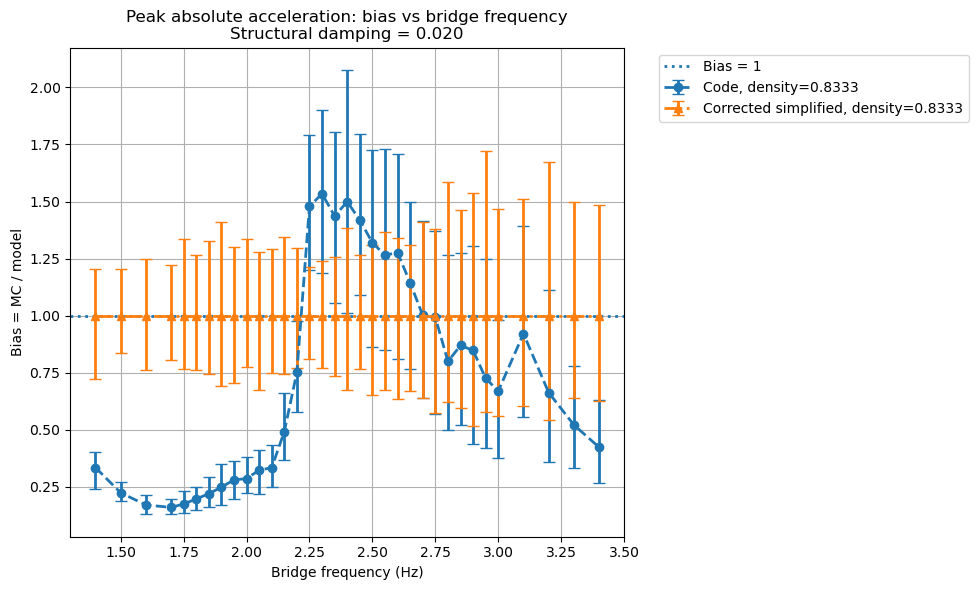

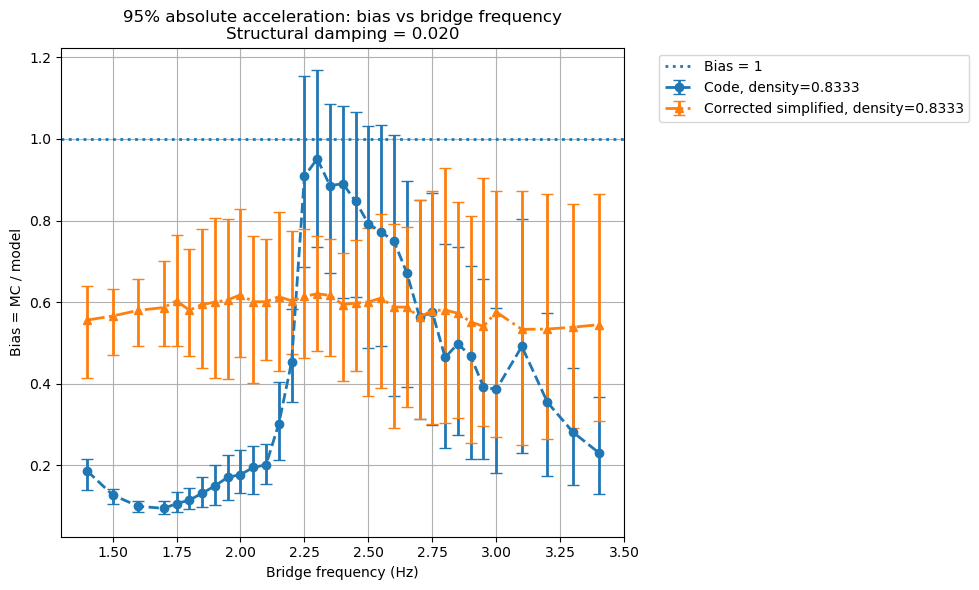

In [15]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [0.8333]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density0.8333_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density0.8333_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()



Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0200
##########################################################################################

RUNNING BRIDGE FREQUENCY = 1.400 Hz

----------------------------------------------------------------------
Running density = 1.0000
----------------------------------------------------------------------
Target density   = 1.0000
Actual density   = 1.0000
Total peds       = 100
Tocity, Outcity  = 5

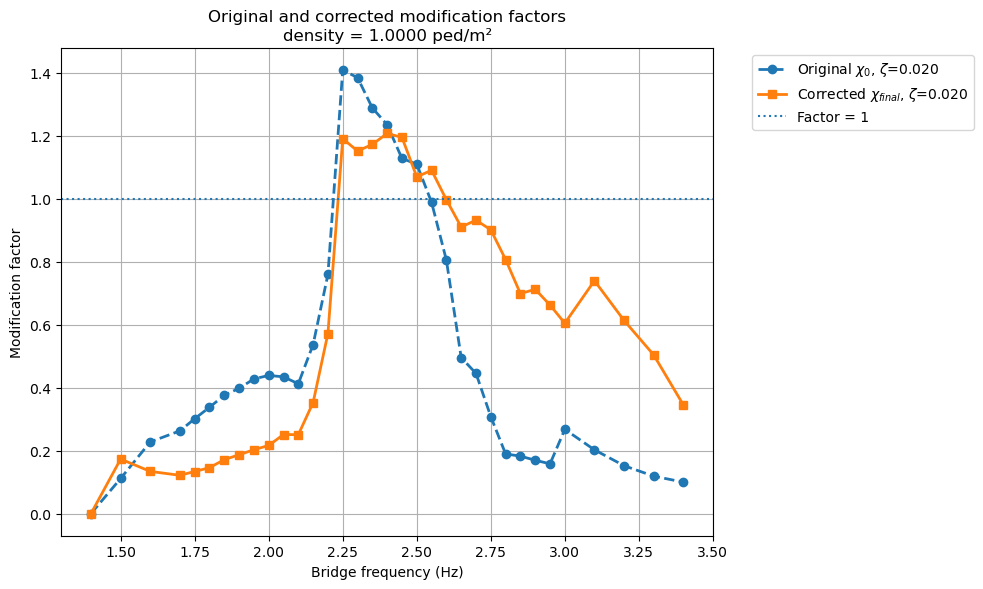

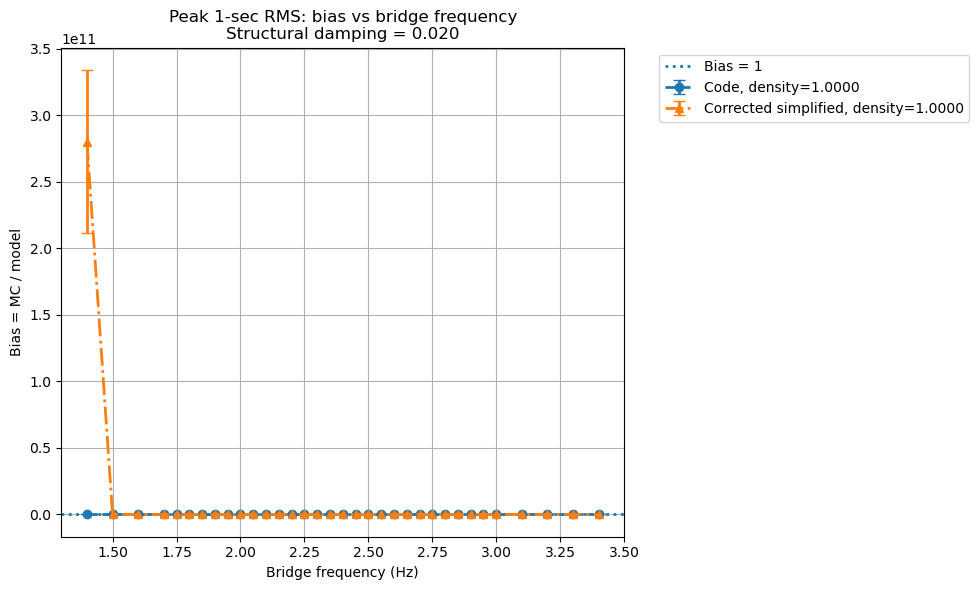

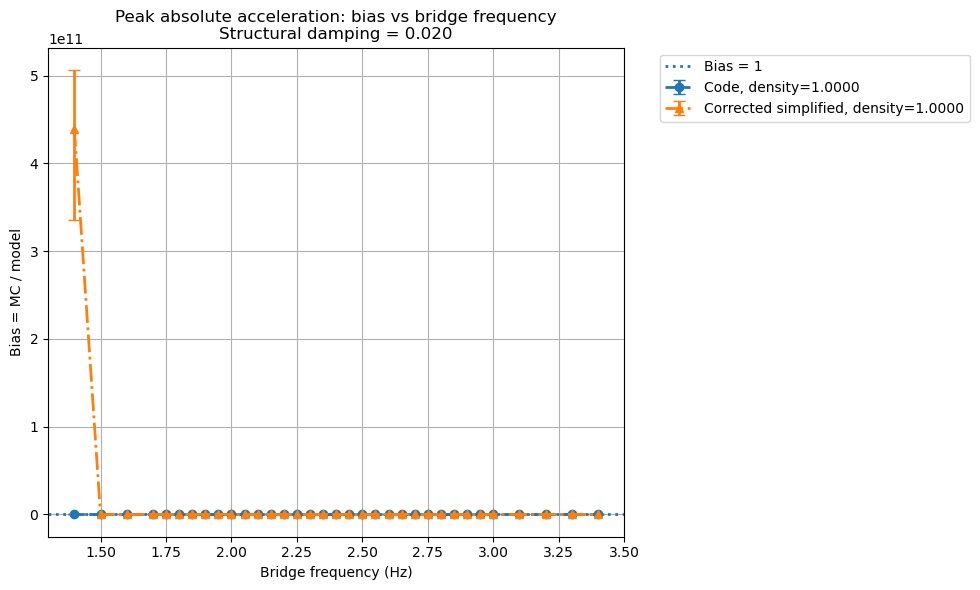

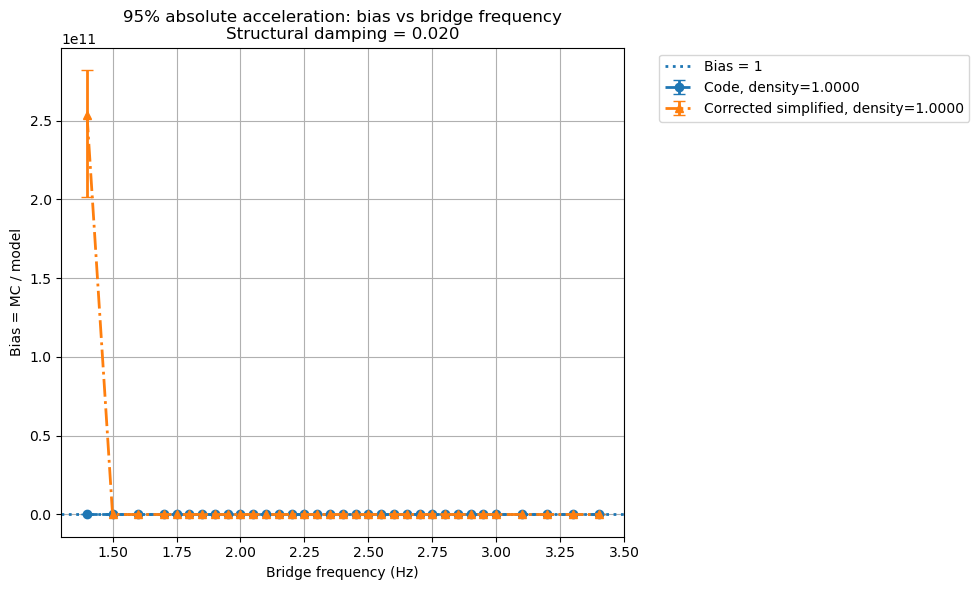

In [16]:
# ==================================================
# MULTI-FREQUENCY + MULTI-DAMPING MC + CODE + CORRECTED SIMPLIFIED SUMMARY
# Outputs:
#   1. original vs corrected modification factor plots
#   2. bias error bars for 3 response measures
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded,
    running_mean_sd_1d,
    running_instantaneous_acc_stats
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Multiple damping ratios
target_beamdamp_values = [0.020]

bridge_frequencies_to_run = [
    1.4, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.4
]

densities_to_run = [1.0000]

eps = 1e-12

# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"

# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database inside main block
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_rows = []
    convergence_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            for target_bf in bridge_frequencies_to_run:

                print("\n" + "=" * 80)
                print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                print("=" * 80)

                BeamFreq = np.array([target_bf, 4.0 * target_bf])
                Beamdamp = np.array([target_beamdamp])

                for density in densities_to_run:

                    print("\n" + "-" * 70)
                    print(f"Running density = {density:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]

                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CONVERGENCE STATISTICS
                    # Instantaneous acceleration + response measures
                    # ==================================================

                    # --------------------------------------------------
                    # A) Instantaneous acceleration convergence
                    # --------------------------------------------------
                    sim_numbers_inst, inst_running_mean, inst_running_sd = (
                        running_instantaneous_acc_stats(accelerations_ss)
                    )

                    all_acc_values = accelerations_ss.reshape(-1)

                    inst_final_mean = np.mean(all_acc_values)
                    inst_final_sd = np.std(all_acc_values, ddof=1)

                    for i, n_sim in enumerate(sim_numbers_inst):

                        convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "quantity": "Instantaneous acceleration",
                            "sim_number": int(n_sim),

                            "running_mean": inst_running_mean[i],
                            "running_sd": inst_running_sd[i],
                            "mean_abs_error": abs(inst_running_mean[i] - inst_final_mean),
                            "sd_abs_error": abs(inst_running_sd[i] - inst_final_sd),
                        })


                    # --------------------------------------------------
                    # B) Response-measure convergence
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        measure_values = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        measure_values = measure_values[np.isfinite(measure_values)]

                        sim_numbers_m, measure_running_mean, measure_running_sd = (
                            running_mean_sd_1d(measure_values)
                        )

                        measure_final_mean = np.mean(measure_values)
                        measure_final_sd = np.std(measure_values, ddof=1)

                        for i, n_sim in enumerate(sim_numbers_m):

                            convergence_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "mean_modal_mass_ratio": overall_mean_mass_ratio,

                            "quantity": measure_name,
                            "sim_number": int(n_sim),

                            "running_mean": measure_running_mean[i],
                            "running_sd": measure_running_sd[i],

                            "mean_abs_error": abs(measure_running_mean[i] - measure_final_mean),
                            "sd_abs_error": abs(measure_running_sd[i] - measure_final_sd),
                        })

                    print("Convergence statistics stored for this case.")
                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor, interp_details = interpolate_modification_factor_banded(
                        results_all=ff_results_all,
                        target_bf=target_bf,
                        target_beamdamp=target_beamdamp,
                        target_mass_ratio=target_mass_ratio_used,
                        damping_values=ff_damping_values,
                        densities=ff_densities,
                        bands_to_combine=ff_bands_to_combine,
                        factor_key="modification_factor"
                    )

                    force_reduction_factor_used = x_factor

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor:.6f}")

                    # --------------------------------------------------
                    # Simplified deterministic model using chi_0
                    # --------------------------------------------------
                    simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=force_reduction_factor_used
                    )

                    # --------------------------------------------------
                    # Residual correction factor lambda
                    # --------------------------------------------------
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    simp_val_cal = simplified_measures[cal_spec["code_key"]]

                    B_simp_cal = Y_cal / max(simp_val_cal, eps)

                    if CORRECTION_STAT == "mean":
                        residual_correction_factor = np.mean(B_simp_cal)

                    elif CORRECTION_STAT == "median":
                        residual_correction_factor = np.percentile(B_simp_cal, 50)

                    elif CORRECTION_STAT == "p95":
                        residual_correction_factor = np.percentile(B_simp_cal, 95)

                    else:
                        raise ValueError(
                            "CORRECTION_STAT must be 'mean', 'median', or 'p95'."
                        )

                    final_modification_factor = x_factor * residual_correction_factor

                    print("\nResidual bias correction")
                    print("------------------------")
                    print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                    print(f"Correction statistic       = {CORRECTION_STAT}")
                    print(f"Initial factor chi_0        = {x_factor:.6f}")
                    print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                    print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=final_modification_factor
                    )

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = Y_ref / max(code_val, eps)
                        B_simp = Y_ref / max(simp_val, eps)
                        B_corr = Y_ref / max(corr_val, eps)

                        summary_rows.append({
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": np.mean(B_code),
                            "code_bias_p5": np.percentile(B_code, 5),
                            "code_bias_p50": np.percentile(B_code, 50),
                            "code_bias_p95": np.percentile(B_code, 95),

                            "simplified_bias_mean": np.mean(B_simp),
                            "simplified_bias_p5": np.percentile(B_simp, 5),
                            "simplified_bias_p50": np.percentile(B_simp, 50),
                            "simplified_bias_p95": np.percentile(B_simp, 95),

                            "corrected_bias_mean": np.mean(B_corr),
                            "corrected_bias_p5": np.percentile(B_corr, 5),
                            "corrected_bias_p50": np.percentile(B_corr, 50),
                            "corrected_bias_p95": np.percentile(B_corr, 95),
                        })

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val:.6f}")
                        print(f"  Simplified prediction     = {simp_val:.6f}")
                        print(f"  Corrected prediction      = {corr_val:.6f}")
                        print(f"  Code mean bias            = {np.mean(B_code):.6f}")
                        print(f"  Simplified mean bias      = {np.mean(B_simp):.6f}")
                        print(f"  Corrected simplified bias = {np.mean(B_corr):.6f}")

    # ==================================================
    # SAVE SUMMARY
    # ==================================================
    summary_df = pd.DataFrame(summary_rows)
    convergence_df = pd.DataFrame(convergence_rows)

    summary_pkl = "density1.0000_damping0.020_0S_bias_summary.pkl"
    #convergence_pkl = "density1.0000_damping0.020_0S_convergence_summary.pkl"

    with open(summary_pkl, "wb") as f:
        pickle.dump(summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    #with open(convergence_pkl, "wb") as f:
        #pickle.dump(convergence_df, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nSaved summary files:")
    print(summary_pkl)
    #print(convergence_pkl)

    # ==================================================
    # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
    # One plot per density, all damping ratios included
    # ==================================================
    factor_df = summary_df.drop_duplicates(
        subset=["bridge_frequency", "target_density", "target_beamdamp"]
    ).copy()

    for density in densities_to_run:

        plt.figure(figsize=(10, 6))

        for target_beamdamp in target_beamdamp_values:

            sub = factor_df[
                (factor_df["target_density"] == density) &
                (factor_df["target_beamdamp"] == target_beamdamp)
            ].copy()

            sub = sub.sort_values("bridge_frequency")

            plt.plot(
                sub["bridge_frequency"],
                sub["initial_modification_factor"],
                marker="o",
                linestyle="--",
                linewidth=2,
                label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
            )

            plt.plot(
                sub["bridge_frequency"],
                sub["final_modification_factor"],
                marker="s",
                linestyle="-",
                linewidth=2,
                label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
            )

        plt.axhline(
            1.0,
            linestyle=":",
            linewidth=1.5,
            label="Factor = 1"
        )

        plt.xlabel("Bridge frequency (Hz)")
        plt.ylabel("Modification factor")
        plt.title(
            f"Original and corrected modification factors\n"
            f"density = {density:.4f} ped/m²"
        )

        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # ==================================================
    # PLOTS 2-4: ERROR BARS FOR EACH RESPONSE MEASURE
    # One plot per vibration measure and damping ratio
    # Only Code and Corrected Simplified are plotted
    # ==================================================
    for target_beamdamp in target_beamdamp_values:

        for measure_name in measure_specs.keys():

            plt.figure(figsize=(10, 6))

            for density in densities_to_run:

                sub = summary_df[
                    (summary_df["target_beamdamp"] == target_beamdamp) &
                    (summary_df["target_density"] == density) &
                    (summary_df["measure"] == measure_name)
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                x = sub["bridge_frequency"].values

                # -----------------------------
                # Original code bias
                # -----------------------------
                y_code = sub["code_bias_mean"].values
                y_code_p5 = sub["code_bias_p5"].values
                y_code_p95 = sub["code_bias_p95"].values

                yerr_code = np.vstack([
                    y_code - y_code_p5,
                    y_code_p95 - y_code
                ])

                plt.errorbar(
                    x,
                    y_code,
                    yerr=yerr_code,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    capsize=4,
                    label=f"Code, density={density:.4f}"
                )

                # -----------------------------
                # Corrected simplified model bias
                # -----------------------------
                y_corr = sub["corrected_bias_mean"].values
                y_corr_p5 = sub["corrected_bias_p5"].values
                y_corr_p95 = sub["corrected_bias_p95"].values

                yerr_corr = np.vstack([
                    y_corr - y_corr_p5,
                    y_corr_p95 - y_corr
                ])

                plt.errorbar(
                    x,
                    y_corr,
                    yerr=yerr_corr,
                    marker="^",
                    linestyle="-.",
                    linewidth=2,
                    capsize=4,
                    label=f"Corrected simplified, density={density:.4f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=2,
                label="Bias = 1"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Bias = MC / model")
            plt.title(
                f"{measure_name}: bias vs bridge frequency\n"
                f"Structural damping = {target_beamdamp:.3f}"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

